# SPY Hybrid ERNN S Cross-lagged

Original unrestricted model tuning with seven separately estimated nominal levels and the Bitcoin rank-based selection procedure.

In [2]:
# ============================================================
# SPY MODELLING DATA PREPARATION
# Common setup for all ERNN and QRNN specifications
# ============================================================

from pathlib import Path
import random
import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------
# 1. Reproducibility and device
# ------------------------------------------------------------

BASE_SEED = 2026

random.seed(BASE_SEED)
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(BASE_SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ------------------------------------------------------------
# 2. Load the scaled SPY dataset
# ------------------------------------------------------------

DATA_PATH = Path.home() / "SPY_features_scaled.csv"

df = pd.read_csv(
    DATA_PATH,
    index_col="Date",
    parse_dates=True
)

df = (
    df
    .sort_index()
    .drop_duplicates()
    .dropna()
    .copy()
)


# ------------------------------------------------------------
# 3. Response and predictors
# ------------------------------------------------------------

target_col = "log_return"

feature_cols = [
    "Volatility",
    "RSI_14",
    "ATR_14",
    "QQQ_LogReturns",
    "VIX_LogChange",
    "Volume_LogChange",
]

required_cols = [target_col] + feature_cols

missing_cols = [
    column
    for column in required_cols
    if column not in df.columns
]

if missing_cols:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_cols)
    )


# ------------------------------------------------------------
# 4. Chronological 70%-15%-15% split
# ------------------------------------------------------------

train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:].copy()


# ------------------------------------------------------------
# 5. Convert samples to tensors
# ------------------------------------------------------------

def dataframe_to_tensors(sample):
    X = torch.tensor(
        sample[feature_cols].to_numpy(),
        dtype=torch.float32,
        device=device
    )
    y = torch.tensor(
        sample[target_col].to_numpy(),
        dtype=torch.float32,
        device=device
    )
    return X, y


X_train, y_train = dataframe_to_tensors(train_df)
X_val, y_val = dataframe_to_tensors(val_df)
X_test, y_test = dataframe_to_tensors(test_df)

# Compatibility aliases used by later QRNN cells.
X_test_q = X_test
y_test_q = y_test

levels = [
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
]

alpha_levels = levels
tau_levels = levels


# ------------------------------------------------------------
# 6. Checks and split summary
# ------------------------------------------------------------

assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)
assert X_train.shape[1] == len(feature_cols)
assert torch.isfinite(X_train).all()
assert torch.isfinite(X_val).all()
assert torch.isfinite(X_test).all()
assert torch.isfinite(y_train).all()
assert torch.isfinite(y_val).all()
assert torch.isfinite(y_test).all()

split_summary = pd.DataFrame({
    "Sample": ["Training", "Validation", "Test"],
    "Observations": [len(train_df), len(val_df), len(test_df)],
    "Start": [
        train_df.index.min().date(),
        val_df.index.min().date(),
        test_df.index.min().date(),
    ],
    "End": [
        train_df.index.max().date(),
        val_df.index.max().date(),
        test_df.index.max().date(),
    ],
})

display(split_summary)

print("Input features:", feature_cols)
print("Number of predictors:", len(feature_cols))
print("X_train shape:", tuple(X_train.shape))
print("X_val shape:  ", tuple(X_val.shape))
print("X_test shape: ", tuple(X_test.shape))


Device: cpu


,Sample,Observations,Start,End
0,Training,2219,2014-01-23,2022-11-11
1,Validation,475,2022-11-14,2024-10-04
2,Test,476,2024-10-07,2026-08-31


Input features: ['Volatility', 'RSI_14', 'ATR_14', 'QQQ_LogReturns', 'VIX_LogChange', 'Volume_LogChange']
Number of predictors: 6
X_train shape: (2219, 6)
X_val shape:   (475, 6)
X_test shape:  (476, 6)


## Original tuning

Run this cell after the SPY data-preparation cell.

In [9]:
# ============================================================
# ORIGINAL TUNING — SPY HYBRID ERNN S CROSS-LAGGED
# Seven separately estimated nominal levels
# 200 Optuna trials per level
# ============================================================

import copy
import json
import time

import optuna
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


MODEL_NAME = "spy_ernn_s_cross"
FORM = "S"
LAG_TYPE = "cross"
N_TRIALS = 200
MAX_EPOCHS = 200

TAU_LEVELS = [
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
]

OUTPUT_DIR = Path("spy_original_tuning_results") / MODEL_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Model:", MODEL_NAME)
print("Output directory:", OUTPUT_DIR.resolve())


# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------

def set_model_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ------------------------------------------------------------
# 2. AGD negative log-likelihood
# ------------------------------------------------------------

def hybrid_ernn_loss(y, expectile_forecast, sigma, tau):
    """Mean asymmetric-Gaussian negative log-likelihood."""

    eps = torch.finfo(expectile_forecast.dtype).eps
    sigma = torch.clamp(sigma, min=eps)

    tau_tensor = torch.as_tensor(
        tau,
        dtype=expectile_forecast.dtype,
        device=expectile_forecast.device,
    )

    difference = y - expectile_forecast

    asymmetric_squared_error = (
        torch.abs(
            tau_tensor
            - (difference < 0).to(expectile_forecast.dtype)
        )
        * difference.pow(2)
    )

    pi_tensor = torch.as_tensor(
        torch.pi,
        dtype=expectile_forecast.dtype,
        device=expectile_forecast.device,
    )

    normalising_constant = (
        torch.log(
            torch.sqrt(pi_tensor / tau_tensor)
            + torch.sqrt(pi_tensor / (1.0 - tau_tensor))
        )
        - torch.log(
            torch.as_tensor(
                2.0,
                dtype=expectile_forecast.dtype,
                device=expectile_forecast.device,
            )
        )
    )

    observation_nll = (
        torch.log(sigma)
        + normalising_constant
        + asymmetric_squared_error / sigma.pow(2)
    )

    return observation_nll.mean()


# ------------------------------------------------------------
# 3. CARE-hybrid recursion
# ------------------------------------------------------------

def compute_hybrid_location(
    y,
    X,
    gamma1,
    gamma2,
    gamma3,
    fnn,
    psi,
):
    """S-form cross-lagged CARE-hybrid recursion."""

    fnn_output = fnn(X).squeeze(-1)
    zero_value = y.new_zeros(())

    care_forecasts = [zero_value]
    hybrid_forecasts = [zero_value]

    for time_index in range(1, len(y)):
        previous_return = y[time_index - 1]

        previous_state = hybrid_forecasts[time_index - 1]
        absolute_return = torch.abs(previous_return)
        care_value = (
            gamma1 * previous_state
            + gamma2 * absolute_return
        )

        hybrid_value = (
            psi * care_value
            + (1.0 - psi) * fnn_output[time_index]
        )

        care_forecasts.append(care_value)
        hybrid_forecasts.append(hybrid_value)

    return (
        torch.stack(hybrid_forecasts),
        torch.stack(care_forecasts),
    )


# ------------------------------------------------------------
# 4. Hybrid ERNN model
# ------------------------------------------------------------

class HybridERNN_S_Cross(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        self.eps = 1e-6

        self.gamma1_raw = nn.Parameter(
            torch.tensor(1.386)
        )

        self.gamma2_raw = nn.Parameter(
            torch.tensor(0.3)
        )

        self.psi_raw = nn.Parameter(
            torch.tensor(0.0)
        )

        self.sigma_raw = nn.Parameter(
            torch.tensor(0.5)
        )

        layers = []
        previous_dimension = input_dim

        for layer_index in range(config["n_hidden_layers"]):
            hidden_dimension = config[f"hidden_dim_{layer_index}"]

            layers.append(
                nn.Linear(previous_dimension, hidden_dimension)
            )

            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dimension))

            layers.append(
                self.get_activation(config["activation"])
            )

            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))

            previous_dimension = hidden_dimension

        layers.append(nn.Linear(previous_dimension, 1))
        self.fnn = nn.Sequential(*layers)

        self.initialise_weights(config["weight_init"])

    @staticmethod
    def get_activation(name):
        return {
            "relu": nn.ReLU(),
            "elu": nn.ELU(),
            "gelu": nn.GELU(),
            "tanh": nn.Tanh(),
        }[name]

    def initialise_weights(self, method):
        for module in self.fnn.modules():
            if not isinstance(module, nn.Linear):
                continue

            if method == "glorot":
                nn.init.xavier_uniform_(module.weight)
            else:
                nn.init.kaiming_uniform_(module.weight)

            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, y, X):
        gamma1 = torch.sigmoid(self.gamma1_raw)
        gamma2 = F.softplus(self.gamma2_raw)

        gamma3 = None
        psi = torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + self.eps

        hybrid_forecast, care_forecast = compute_hybrid_location(
            y=y,
            X=X,
            gamma1=gamma1,
            gamma2=gamma2,
            gamma3=gamma3,
            fnn=self.fnn,
            psi=psi,
        )

        return hybrid_forecast, sigma, care_forecast


# ------------------------------------------------------------
# 5. Original Bitcoin coverage-ratio ranking diagnostic
# ------------------------------------------------------------

def calculate_crp(y, forecast, tau):
    if tau <= 0.5:
        empirical_probability = (
            y <= forecast
        ).float().mean().item()
        target_probability = tau
    else:
        empirical_probability = (
            y > forecast
        ).float().mean().item()
        target_probability = 1.0 - tau

    crp = empirical_probability / target_probability
    crp_penalty = (crp - 1.0) ** 2

    return crp, crp_penalty, empirical_probability


# ------------------------------------------------------------
# 6. Optuna search space
# ------------------------------------------------------------

def suggest_ernn_config(trial):
    config = {
        "n_hidden_layers": trial.suggest_int(
            "n_hidden_layers", 1, 3
        ),
        "activation": trial.suggest_categorical(
            "activation", ["relu", "elu", "gelu", "tanh"]
        ),
        "dropout": trial.suggest_float(
            "dropout", 0.0, 0.5
        ),
        "layernorm": trial.suggest_categorical(
            "layernorm", [True, False]
        ),
        "weight_init": trial.suggest_categorical(
            "weight_init", ["glorot", "he"]
        ),
        "lr": trial.suggest_float(
            "lr", 1e-4, 5e-2, log=True
        ),
        "optimizer": trial.suggest_categorical(
            "optimizer", ["adam", "adamw"]
        ),
        "weight_decay": trial.suggest_float(
            "weight_decay", 0.0, 1e-4
        ),
        "gradient_clip": trial.suggest_categorical(
            "gradient_clip", [0.1, 1.0, 5.0]
        ),
        "patience": trial.suggest_categorical(
            "patience", [10, 20, 30]
        ),
    }

    for layer_index in range(config["n_hidden_layers"]):
        config[f"hidden_dim_{layer_index}"] = trial.suggest_int(
            f"hidden_dim_{layer_index}", 32, 256
        )

    return config


def make_optimizer(model, config):
    arguments = {
        "params": model.parameters(),
        "lr": config["lr"],
        "weight_decay": config["weight_decay"],
    }

    if config["optimizer"] == "adam":
        return torch.optim.Adam(**arguments)

    return torch.optim.AdamW(**arguments)


# ------------------------------------------------------------
# 7. Fit one trial configuration
# ------------------------------------------------------------

def train_ernn_configuration(config, tau, model_seed=BASE_SEED):
    set_model_seed(model_seed)

    model = HybridERNN_S_Cross(
        input_dim=X_train.shape[1],
        config=config,
    ).to(device)

    optimizer = make_optimizer(model, config)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=10,
        factor=0.5,
        min_lr=1e-6,
    )

    best_validation_nll = np.inf
    best_model_state = None
    patience_counter = 0
    epochs_completed = 0

    for epoch in range(MAX_EPOCHS):
        epochs_completed = epoch + 1

        model.train()
        optimizer.zero_grad()

        train_forecast, train_sigma, _ = model(y_train, X_train)

        train_loss = hybrid_ernn_loss(
            y=y_train,
            expectile_forecast=train_forecast,
            sigma=train_sigma,
            tau=tau,
        )

        if not torch.isfinite(train_loss):
            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config["gradient_clip"],
        )

        optimizer.step()

        model.eval()

        with torch.no_grad():
            validation_forecast, validation_sigma, _ = model(
                y_val,
                X_val,
            )

            validation_loss = hybrid_ernn_loss(
                y=y_val,
                expectile_forecast=validation_forecast,
                sigma=validation_sigma,
                tau=tau,
            )

        if not torch.isfinite(validation_loss):
            return None

        scheduler.step(validation_loss)
        current_validation_nll = validation_loss.item()

        if current_validation_nll < best_validation_nll:
            best_validation_nll = current_validation_nll
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

            if patience_counter >= config["patience"]:
                break

    if best_model_state is None:
        return None

    model.load_state_dict(best_model_state)
    model.eval()

    with torch.no_grad():
        validation_forecast, validation_sigma, _ = model(y_val, X_val)

        validation_nll = hybrid_ernn_loss(
            y=y_val,
            expectile_forecast=validation_forecast,
            sigma=validation_sigma,
            tau=tau,
        ).item()

        (
            validation_crp,
            validation_crp_penalty,
            validation_hit_rate,
        ) = calculate_crp(
            y=y_val,
            forecast=validation_forecast,
            tau=tau,
        )

    parameters = {
        "gamma1": torch.sigmoid(model.gamma1_raw).item(),
        "gamma2": F.softplus(model.gamma2_raw).item(),
        "gamma3": np.nan,
        "psi": torch.sigmoid(model.psi_raw).item(),
        "sigma": (F.softplus(model.sigma_raw) + model.eps).item(),
    }

    return {
        "model": model,
        "validation_nll": validation_nll,
        "validation_crp": validation_crp,
        "validation_crp_penalty": validation_crp_penalty,
        "validation_hit_rate": validation_hit_rate,
        "epochs_completed": epochs_completed,
        **parameters,
    }


# ------------------------------------------------------------
# 8. Optuna objective and rank-based selection
# ------------------------------------------------------------

def objective_ernn(trial, tau):
    config = suggest_ernn_config(trial)
    result = train_ernn_configuration(config, tau)

    if result is None:
        raise optuna.TrialPruned(
            "Non-finite loss or no valid checkpoint."
        )

    for name in [
        "validation_nll",
        "validation_crp",
        "validation_crp_penalty",
        "validation_hit_rate",
        "epochs_completed",
        "gamma1",
        "gamma2",
        "gamma3",
        "psi",
        "sigma",
    ]:
        trial.set_user_attr(name, result[name])

    return result["validation_nll"]


def rank_completed_trials(study):
    completed_trials = [
        trial
        for trial in study.trials
        if (
            trial.state == optuna.trial.TrialState.COMPLETE
            and trial.value is not None
            and np.isfinite(trial.value)
            and "validation_crp_penalty" in trial.user_attrs
        )
    ]

    if not completed_trials:
        raise RuntimeError("No valid completed Optuna trials.")

    nll_order = sorted(
        completed_trials,
        key=lambda trial: trial.user_attrs["validation_nll"],
    )

    crp_order = sorted(
        completed_trials,
        key=lambda trial: trial.user_attrs[
            "validation_crp_penalty"
        ],
    )

    nll_ranks = {
        trial.number: rank
        for rank, trial in enumerate(nll_order, start=1)
    }

    crp_ranks = {
        trial.number: rank
        for rank, trial in enumerate(crp_order, start=1)
    }

    ranking_records = []

    for trial in completed_trials:
        rank_nll = nll_ranks[trial.number]
        rank_crp = crp_ranks[trial.number]

        ranking_records.append({
            "trial": trial.number,
            **trial.user_attrs,
            "rank_nll": rank_nll,
            "rank_crp": rank_crp,
            "sum_rank": rank_nll + rank_crp,
            **trial.params,
        })

    ranking_table = pd.DataFrame(ranking_records)

    ranking_table = ranking_table.sort_values(
        [
            "sum_rank",
            "validation_nll",
            "validation_crp_penalty",
            "trial",
        ]
    ).reset_index(drop=True)

    selected_trial_number = int(ranking_table.iloc[0]["trial"])

    selected_trial = next(
        trial
        for trial in completed_trials
        if trial.number == selected_trial_number
    )

    return selected_trial, ranking_table


# ------------------------------------------------------------
# 9. Run 200 trials at each nominal level
# ------------------------------------------------------------

best_configs_spy_ernn_s_cross = {}
best_models_spy_ernn_s_cross = {}
summary_records = []

overall_start_time = time.time()

for level_index, tau in enumerate(TAU_LEVELS):
    level_start_time = time.time()
    sampler_seed = BASE_SEED + level_index

    print("\n" + "=" * 72)
    print(f"Tuning {MODEL_NAME} at tau={tau:.3f}")
    print(f"Trials={N_TRIALS} | sampler seed={sampler_seed}")
    print("=" * 72)

    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=sampler_seed),
        study_name=f"{MODEL_NAME}_tau_{tau:.3f}",
    )

    study.optimize(
        lambda trial, current_tau=tau: objective_ernn(
            trial,
            current_tau,
        ),
        n_trials=N_TRIALS,
        show_progress_bar=True,
        gc_after_trial=True,
    )

    selected_trial, ranking_table = rank_completed_trials(study)
    tau_label = f"{tau:.3f}"

    ranking_table.insert(0, "tau", tau)

    ranking_path = OUTPUT_DIR / (
        f"{MODEL_NAME}_ranking_tau_{tau_label}.csv"
    )

    ranking_table.to_csv(ranking_path, index=False)

    selected_config = selected_trial.params.copy()

    selected_result = train_ernn_configuration(
        selected_config,
        tau,
    )

    if selected_result is None:
        raise RuntimeError(
            f"Selected trial could not be reproduced for tau={tau}."
        )

    selected_model = selected_result["model"]

    checkpoint_path = OUTPUT_DIR / (
        f"{MODEL_NAME}_best_tau_{tau_label}.pt"
    )

    torch.save(
        {
            "model_name": MODEL_NAME,
            "asset": "SPY",
            "form": FORM,
            "lag_type": LAG_TYPE,
            "tau": tau,
            "selected_trial": selected_trial.number,
            "config": selected_config,
            "model_state_dict": {
                key: value.detach().cpu()
                for key, value in selected_model.state_dict().items()
            },
            "validation_nll": selected_result["validation_nll"],
            "validation_crp": selected_result["validation_crp"],
            "validation_crp_penalty": selected_result[
                "validation_crp_penalty"
            ],
            "validation_hit_rate": selected_result[
                "validation_hit_rate"
            ],
            "estimated_parameters": {
                name: selected_result[name]
                for name in [
                    "gamma1",
                    "gamma2",
                    "gamma3",
                    "psi",
                    "sigma",
                ]
            },
            "feature_cols": feature_cols,
            "number_of_trials": N_TRIALS,
            "base_seed": BASE_SEED,
            "sampler_seed": sampler_seed,
        },
        checkpoint_path,
    )

    selected_record = {
        **selected_config,
        "selected_trial": selected_trial.number,
        **{
            name: selected_result[name]
            for name in [
                "validation_nll",
                "validation_crp",
                "validation_crp_penalty",
                "validation_hit_rate",
                "gamma1",
                "gamma2",
                "gamma3",
                "psi",
                "sigma",
            ]
        },
    }

    best_configs_spy_ernn_s_cross[tau] = selected_record
    best_models_spy_ernn_s_cross[tau] = selected_model

    runtime_hours = (
        time.time() - level_start_time
    ) / 3600

    summary_records.append({
        "tau": tau,
        "selected_trial": selected_trial.number,
        "validation_nll": selected_result["validation_nll"],
        "validation_crp": selected_result["validation_crp"],
        "validation_crp_penalty": selected_result[
            "validation_crp_penalty"
        ],
        "validation_hit_rate": selected_result[
            "validation_hit_rate"
        ],
        "gamma1": selected_result["gamma1"],
        "gamma2": selected_result["gamma2"],
        "gamma3": selected_result["gamma3"],
        "psi": selected_result["psi"],
        "sigma": selected_result["sigma"],
        "valid_trials": len(ranking_table),
        "runtime_hours": runtime_hours,
    })

    print("\nTop 10 rank-based trials:")
    print(
        ranking_table[[
            "trial",
            "validation_nll",
            "validation_crp",
            "validation_crp_penalty",
            "rank_nll",
            "rank_crp",
            "sum_rank",
        ]].head(10).to_string(index=False)
    )

    print("\nSelected trial:", selected_trial.number)
    print(
        "Validation NLL:",
        f"{selected_result['validation_nll']:.8f}",
    )
    print(
        "Validation CRP:",
        f"{selected_result['validation_crp']:.8f}",
    )
    print("Ranking saved to:", ranking_path)
    print("Checkpoint saved to:", checkpoint_path)


summary_spy_ernn_s_cross = pd.DataFrame(summary_records)

summary_path = OUTPUT_DIR / f"{MODEL_NAME}_tuning_summary.csv"
summary_spy_ernn_s_cross.to_csv(summary_path, index=False)

config_path = OUTPUT_DIR / f"{MODEL_NAME}_selected_configs.json"

with open(config_path, "w") as configuration_file:
    json.dump(
        {
            f"{tau:.3f}": config
            for tau, config in best_configs_spy_ernn_s_cross.items()
        },
        configuration_file,
        indent=2,
    )

print("\n" + "=" * 72)
print("SPY ORIGINAL ERNN TUNING COMPLETED:", MODEL_NAME)
print("=" * 72)
display(summary_spy_ernn_s_cross)

print(
    "Total runtime (hours):",
    f"{(time.time() - overall_start_time) / 3600:.3f}",
)
print("Summary saved to:", summary_path)
print("Selected configurations saved to:", config_path)


[I 2026-09-21 10:31:45,673] A new study created in memory with name: spy_ernn_s_cross_tau_0.025


Model: spy_ernn_s_cross
Output directory: /Users/miaomiaochen/Desktop/PhD program/Project 1/spy_original_tuning_results/spy_ernn_s_cross

Tuning spy_ernn_s_cross at tau=0.025
Trials=200 | sampler seed=2026


  0%|          | 0/200 [00:00<?, ?it/s]

[W 2026-09-21 10:31:49,567] Trial 0 failed with parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/0k/3jhs8p2d2bdd3_fvs731s4cr0000gn/T/ipykernel_72271/4231191321.py", line 590, in <lambda>
    lambda trial, current_tau=tau: objective_ernn(
                                   ^^^^^^^^^^^^^^^
  File "/var/folders/0k/3jhs8p2d2bdd3_fvs731s4cr0000gn/T/ipykernel_72271/4231191321.py", line 466, in objective_ernn
    result = train_ernn_configuration(config, tau)
             ^^^^^^^^^^^^^^^^^^^^^^

KeyboardInterrupt: 

## Test evaluation and plotting


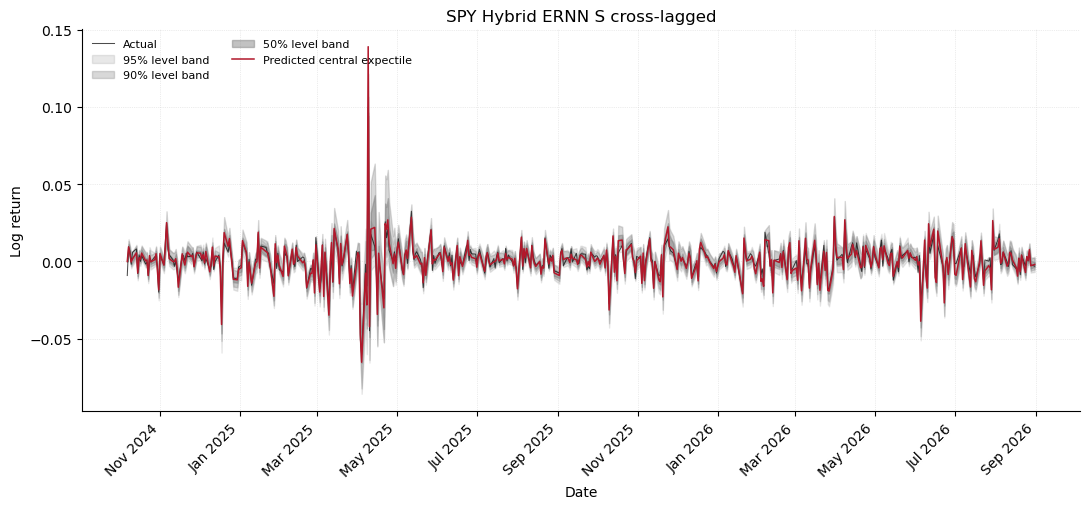

TEST METRICS — SPY HYBRID ERNN S CROSS-LAGGED
       tau         NLL        ASE   Hit_Rate      Sigma  Selected_Trial
0.02500000 -3.79087400 0.00000221 0.01050420 0.00215520             139
0.05000000 -3.95501137 0.00000276 0.08613445 0.00209137             182
0.25000000 -4.17619658 0.00000510 0.18487395 0.00398135             128
0.50000000 -4.15743065 0.00000700 0.45378151 0.00419301             171
0.75000000 -3.88060927 0.00000868 0.68277311 0.00559434             185
0.95000000 -3.79089141 0.00000390 0.97899160 0.00258210              60
0.97500000 -3.67262840 0.00000281 0.98319328 0.00240251             112

Average NLL: -3.917663
Average ASE: 0.00000464
Total crossovers: 291
Tail violations: 241

Plot saved to:
spy_original_tuning_results/spy_ernn_s_cross/spy_ernn_s_cross_test_predictions.png

All test results saved under:
spy_original_tuning_results/spy_ernn_s_cross


In [11]:
# ============================================================
# TEST EVALUATION AND PLOTTING
# SPY HYBRID ERNN S — CROSS-LAGGED
# Loads saved checkpoints; no retuning is required
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ------------------------------------------------------------
# 1. Settings
# ------------------------------------------------------------

EVALUATION_LEVELS = [
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
]

EVALUATION_FORM = "S"
EVALUATION_LAG = "Cross"
EVALUATION_MODEL_NAME = "spy_ernn_s_cross"

EVALUATION_DIR = (
    Path("spy_original_tuning_results")
    / EVALUATION_MODEL_NAME
)

if not EVALUATION_DIR.exists():
    raise FileNotFoundError(
        f"Result directory not found: {EVALUATION_DIR.resolve()}"
    )

required_data_objects = ["X_test", "y_test", "test_df", "device"]
missing_data_objects = [
    name for name in required_data_objects
    if name not in globals()
]

if missing_data_objects:
    raise RuntimeError(
        "Run the SPY data-preparation cell first. Missing: "
        + ", ".join(missing_data_objects)
    )


# ------------------------------------------------------------
# 2. Standalone model reconstruction
# ------------------------------------------------------------

class EvaluationHybridERNN(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        self.eps = 1e-6
        self.gamma1_raw = nn.Parameter(torch.tensor(1.386))
        self.gamma2_raw = nn.Parameter(torch.tensor(0.3))

        if EVALUATION_FORM != "S":
            self.gamma3_raw = nn.Parameter(torch.tensor(0.3))

        self.psi_raw = nn.Parameter(torch.tensor(0.0))
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        layers = []
        previous_dimension = input_dim

        for layer_index in range(config["n_hidden_layers"]):
            hidden_dimension = config[f"hidden_dim_{layer_index}"]
            layers.append(
                nn.Linear(previous_dimension, hidden_dimension)
            )

            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dimension))

            layers.append({
                "relu": nn.ReLU(),
                "elu": nn.ELU(),
                "gelu": nn.GELU(),
                "tanh": nn.Tanh(),
            }[config["activation"]])

            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))

            previous_dimension = hidden_dimension

        layers.append(nn.Linear(previous_dimension, 1))
        self.fnn = nn.Sequential(*layers)

    def forward(self, y, X):
        gamma1 = torch.sigmoid(self.gamma1_raw)
        gamma2 = F.softplus(self.gamma2_raw)
        gamma3 = (
            F.softplus(self.gamma3_raw)
            if EVALUATION_FORM != "S"
            else None
        )
        psi = torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + self.eps

        fnn_output = self.fnn(X).squeeze(-1)
        zero_value = y.new_zeros(())
        care_forecasts = [zero_value]
        hybrid_forecasts = [zero_value]

        for time_index in range(1, len(y)):
            previous_return = y[time_index - 1]
            previous_state = (
                care_forecasts[time_index - 1]
                if EVALUATION_LAG == "Self"
                else hybrid_forecasts[time_index - 1]
            )

            if EVALUATION_FORM == "S":
                care_value = (
                    gamma1 * previous_state
                    + gamma2 * torch.abs(previous_return)
                )
            elif EVALUATION_FORM == "A":
                positive_return = torch.clamp(previous_return, min=0)
                negative_return = torch.clamp(-previous_return, min=0)
                care_value = (
                    gamma1 * previous_state
                    + gamma2 * positive_return
                    + gamma3 * negative_return
                )
            else:
                absolute_return = torch.abs(previous_return)
                care_value = (
                    gamma1 * previous_state
                    + gamma2 * absolute_return
                    + gamma3 * previous_state * absolute_return
                )

            hybrid_value = (
                psi * care_value
                + (1.0 - psi) * fnn_output[time_index]
            )

            care_forecasts.append(care_value)
            hybrid_forecasts.append(hybrid_value)

        return (
            torch.stack(hybrid_forecasts),
            sigma,
            torch.stack(care_forecasts),
        )


def evaluation_agd_components(y, forecast, sigma, tau):
    sigma = torch.clamp(
        sigma,
        min=torch.finfo(forecast.dtype).eps,
    )
    tau_tensor = torch.as_tensor(
        tau,
        dtype=forecast.dtype,
        device=forecast.device,
    )
    residual = y - forecast
    asymmetric_squared_error = (
        torch.abs(
            tau_tensor
            - (residual < 0).to(forecast.dtype)
        )
        * residual.pow(2)
    )
    pi_tensor = torch.as_tensor(
        torch.pi,
        dtype=forecast.dtype,
        device=forecast.device,
    )
    normalising_constant = (
        torch.log(
            torch.sqrt(pi_tensor / tau_tensor)
            + torch.sqrt(pi_tensor / (1.0 - tau_tensor))
        )
        - torch.log(
            torch.as_tensor(
                2.0,
                dtype=forecast.dtype,
                device=forecast.device,
            )
        )
    )
    observation_nll = (
        torch.log(sigma)
        + normalising_constant
        + asymmetric_squared_error / sigma.pow(2)
    )
    return observation_nll, asymmetric_squared_error


# ------------------------------------------------------------
# 3. Load selected checkpoints and forecast the test sample
# ------------------------------------------------------------

test_forecast_columns = []
test_nll_columns = []
test_metric_records = []

for tau in EVALUATION_LEVELS:
    tau_label = f"{tau:.3f}"
    checkpoint_path = EVALUATION_DIR / (
        f"{EVALUATION_MODEL_NAME}_best_tau_{tau_label}.pt"
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Missing checkpoint: {checkpoint_path.resolve()}"
        )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    model = EvaluationHybridERNN(
        input_dim=X_test.shape[1],
        config=checkpoint["config"],
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    with torch.no_grad():
        forecast, sigma, _ = model(y_test, X_test)
        observation_nll, observation_ase = evaluation_agd_components(
            y=y_test,
            forecast=forecast,
            sigma=sigma,
            tau=tau,
        )

    forecast_np = forecast.detach().cpu().numpy()
    nll_np = observation_nll.detach().cpu().numpy()
    ase_np = observation_ase.detach().cpu().numpy()
    y_np = y_test.detach().cpu().numpy()
    hit_rate = float(np.mean(y_np <= forecast_np))

    test_forecast_columns.append(forecast_np)
    test_nll_columns.append(nll_np)
    test_metric_records.append({
        "tau": tau,
        "NLL": float(np.mean(nll_np)),
        "ASE": float(np.mean(ase_np)),
        "Hit_Rate": hit_rate,
        "Sigma": float(sigma.detach().cpu().item()),
        "Selected_Trial": checkpoint["selected_trial"],
    })

test_forecast_matrix = np.column_stack(test_forecast_columns)
test_nll_matrix = np.column_stack(test_nll_columns)
test_metrics = pd.DataFrame(test_metric_records)


# ------------------------------------------------------------
# 4. Crossover diagnostics
# ------------------------------------------------------------

crossover_records = []
total_crossovers = 0
tail_crossovers = 0

for pair_index in range(len(EVALUATION_LEVELS) - 1):
    lower_level = EVALUATION_LEVELS[pair_index]
    upper_level = EVALUATION_LEVELS[pair_index + 1]
    violation_mask = (
        test_forecast_matrix[:, pair_index]
        > test_forecast_matrix[:, pair_index + 1]
    )
    violations = int(violation_mask.sum())
    is_tail_pair = pair_index in {0, len(EVALUATION_LEVELS) - 2}
    total_crossovers += violations
    if is_tail_pair:
        tail_crossovers += violations

    crossover_records.append({
        "Lower_Tau": lower_level,
        "Upper_Tau": upper_level,
        "Violations": violations,
        "Violation_Rate": violations / len(test_df),
        "Tail_Pair": is_tail_pair,
    })

crossover_table = pd.DataFrame(crossover_records)


# ------------------------------------------------------------
# 5. Save predictions, metrics and observation-level NLL
# ------------------------------------------------------------

predictions_table = pd.DataFrame({
    "Date": test_df.index,
    "Actual": y_test.detach().cpu().numpy(),
})

for level_index, tau in enumerate(EVALUATION_LEVELS):
    predictions_table[f"e_{tau:.3f}"] = (
        test_forecast_matrix[:, level_index]
    )

nll_table = pd.DataFrame({"Date": test_df.index})
for level_index, tau in enumerate(EVALUATION_LEVELS):
    nll_table[f"nll_{tau:.3f}"] = test_nll_matrix[:, level_index]
nll_table["average_nll"] = test_nll_matrix.mean(axis=1)

predictions_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_predictions.csv"
)
metrics_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_metrics.csv"
)
nll_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_nll_by_date.csv"
)
crossover_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_crossovers.csv"
)

predictions_table.to_csv(predictions_path, index=False)
test_metrics.to_csv(metrics_path, index=False)
nll_table.to_csv(nll_path, index=False)
crossover_table.to_csv(crossover_path, index=False)


# ------------------------------------------------------------
# 6. Bitcoin-style plot: black actual, red median, grey bands
# ------------------------------------------------------------

dates = pd.to_datetime(test_df.index)
actual = y_test.detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(11, 5.2))

ax.plot(
    dates,
    actual,
    color="black",
    linewidth=0.75,
    alpha=0.70,
    label="Actual",
)
ax.fill_between(
    dates,
    test_forecast_matrix[:, 0],
    test_forecast_matrix[:, 6],
    color="grey",
    alpha=0.18,
    label="95% level band",
)
ax.fill_between(
    dates,
    test_forecast_matrix[:, 1],
    test_forecast_matrix[:, 5],
    color="grey",
    alpha=0.30,
    label="90% level band",
)
ax.fill_between(
    dates,
    test_forecast_matrix[:, 2],
    test_forecast_matrix[:, 4],
    color="grey",
    alpha=0.48,
    label="50% level band",
)
ax.plot(
    dates,
    test_forecast_matrix[:, 3],
    color="#B2182B",
    linewidth=1.1,
    label="Predicted central expectile",
)

ax.set(
    title="SPY Hybrid ERNN S cross-lagged",
    xlabel="Date",
    ylabel="Log return",
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(
    ax.xaxis.get_majorticklabels(),
    rotation=45,
    ha="right",
)
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper left")
fig.tight_layout()

plot_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_predictions.png"
)
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 7. Report
# ------------------------------------------------------------

print("=" * 76)
print("TEST METRICS — SPY HYBRID ERNN S CROSS-LAGGED")
print("=" * 76)
print(test_metrics.to_string(index=False, float_format=lambda x: f"{x:.8f}"))
print(f"\nAverage NLL: {test_metrics['NLL'].mean():.6f}")
print(f"Average ASE: {test_metrics['ASE'].mean():.8f}")
print(f"Total crossovers: {total_crossovers}")
print(f"Tail violations: {tail_crossovers}")
print(f"\nPlot saved to:\n{plot_path}")
print(f"\nAll test results saved under:\n{EVALUATION_DIR}")


## Crossover - Sorting


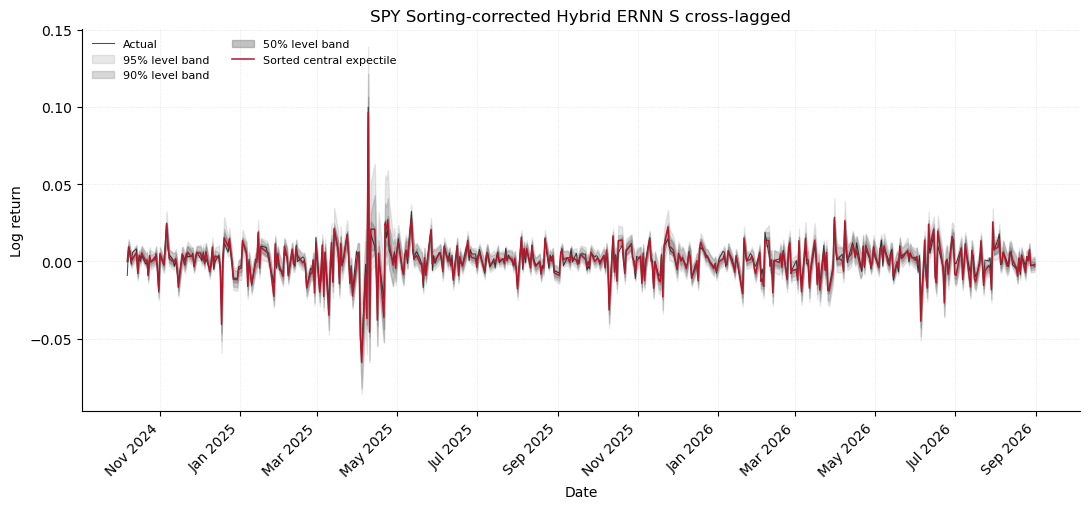

TEST METRICS — SORTING SPY ERNN S CROSS-LAGGED
       tau     raw_nll  sorted_nll    raw_ase  sorted_ase  raw_hit_rate  sorted_hit_rate  mean_absolute_adjustment
0.02500000 -3.79087425 -3.79041859 0.00000221  0.00000222    0.01050420       0.01050420                0.00000138
0.05000000 -3.95501175 -3.96416149 0.00000276  0.00000272    0.08613445       0.07983193                0.00009451
0.25000000 -4.17619670 -4.15750206 0.00000510  0.00000540    0.18487395       0.18907563                0.00005076
0.50000000 -4.15743061 -4.21917423 0.00000700  0.00000591    0.45378151       0.44117647                0.00018445
0.75000000 -3.88060948 -3.98578401 0.00000868  0.00000539    0.68277311       0.69327731                0.00034594
0.95000000 -3.79089149 -4.03796681 0.00000390  0.00000225    0.97899160       0.97058824                0.00130146
0.97500000 -3.67262798 -3.74196448 0.00000281  0.00000241    0.98319328       0.99579832                0.00166555

Raw average NLL:       -3.917663

In [14]:
# ============================================================
# CROSSOVER METHOD: SORTING
# SPY HYBRID ERNN S — CROSS-LAGGED
# Uses saved unrestricted forecasts; no retuning is required
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

LEVELS = np.array([
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975,
], dtype=float)

MODEL_NAME = "spy_ernn_s_cross"
ORIGINAL_DIR = Path("spy_original_tuning_results") / MODEL_NAME
OUTPUT_DIR = Path("spy_sorting_crossover_results") / MODEL_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

prediction_path = ORIGINAL_DIR / f"{MODEL_NAME}_test_predictions.csv"
metric_path = ORIGINAL_DIR / f"{MODEL_NAME}_test_metrics.csv"

if not prediction_path.exists() or not metric_path.exists():
    raise FileNotFoundError(
        "Run the original ERNN test-evaluation cell first. "
        "Do not rerun Optuna."
    )

raw_table = pd.read_csv(prediction_path, parse_dates=["Date"])
original_metrics = pd.read_csv(metric_path)
forecast_columns = [f"e_{tau:.3f}" for tau in LEVELS]

missing_columns = [
    name for name in ["Date", "Actual", *forecast_columns]
    if name not in raw_table.columns
]
if missing_columns:
    raise ValueError(
        "Missing prediction columns: " + ", ".join(missing_columns)
    )

raw_forecasts = raw_table[forecast_columns].to_numpy(dtype=float)
actual = raw_table["Actual"].to_numpy(dtype=float)
dates = pd.to_datetime(raw_table["Date"])

sigma_by_level = (
    original_metrics
    .assign(tau=original_metrics["tau"].astype(float))
    .set_index("tau")["Sigma"]
)


def agd_components(y, forecast, sigma, tau):
    sigma = max(float(sigma), np.finfo(float).eps)
    residual = y - forecast
    weight = np.abs(float(tau) - (residual < 0.0).astype(float))
    ase = weight * residual ** 2
    constant = (
        np.log(
            np.sqrt(np.pi / float(tau))
            + np.sqrt(np.pi / (1.0 - float(tau)))
        )
        - np.log(2.0)
    )
    nll = np.log(sigma) + constant + ase / sigma ** 2
    return nll, ase


def crossover_summary(matrix):
    records = []
    total = 0
    tail = 0
    for pair_index in range(len(LEVELS) - 1):
        mask = matrix[:, pair_index] > matrix[:, pair_index + 1]
        count = int(mask.sum())
        is_tail = pair_index in {0, len(LEVELS) - 2}
        total += count
        if is_tail:
            tail += count
        records.append({
            "lower_tau": LEVELS[pair_index],
            "upper_tau": LEVELS[pair_index + 1],
            "violations": count,
            "violation_rate": count / len(matrix),
            "tail_pair": is_tail,
        })
    return total, tail, pd.DataFrame(records)


# Sort the seven forecasts within every test observation.
adjusted_forecasts = np.sort(raw_forecasts, axis=1)


# ------------------------------------------------------------
# Recalculate AGD NLL and ASE after Sorting
# ------------------------------------------------------------

metric_records = []
raw_nll_columns = []
adjusted_nll_columns = []

for level_index, tau in enumerate(LEVELS):
    sigma = float(sigma_by_level.loc[tau])
    raw_value = raw_forecasts[:, level_index]
    adjusted_value = adjusted_forecasts[:, level_index]

    raw_nll, raw_ase = agd_components(
        actual, raw_value, sigma, tau
    )
    adjusted_nll, adjusted_ase = agd_components(
        actual, adjusted_value, sigma, tau
    )

    raw_hit = float(np.mean(actual <= raw_value))
    adjusted_hit = float(np.mean(actual <= adjusted_value))
    raw_nll_columns.append(raw_nll)
    adjusted_nll_columns.append(adjusted_nll)

    metric_records.append({
        "tau": tau,
        "raw_nll": float(np.mean(raw_nll)),
        "sorted_nll": float(np.mean(adjusted_nll)),
        "raw_ase": float(np.mean(raw_ase)),
        "sorted_ase": float(np.mean(adjusted_ase)),
        "raw_hit_rate": raw_hit,
        "sorted_hit_rate": adjusted_hit,
        "mean_absolute_adjustment": float(
            np.mean(np.abs(adjusted_value - raw_value))
        ),
    })

result_metrics = pd.DataFrame(metric_records)
raw_nll_matrix = np.column_stack(raw_nll_columns)
adjusted_nll_matrix = np.column_stack(adjusted_nll_columns)

raw_crossover, raw_tail, raw_crossovers = crossover_summary(
    raw_forecasts
)
adjusted_crossover, adjusted_tail, adjusted_crossovers = (
    crossover_summary(adjusted_forecasts)
)

adjustments = adjusted_forecasts - raw_forecasts
changed_rows = np.any(
    ~np.isclose(adjustments, 0.0, atol=1e-12),
    axis=1,
)


# ------------------------------------------------------------
# Save detailed outputs
# ------------------------------------------------------------

prediction_output = pd.DataFrame({
    "Date": dates,
    "Actual": actual,
})
for level_index, tau in enumerate(LEVELS):
    prediction_output[f"raw_e_{tau:.3f}"] = raw_forecasts[:, level_index]
    prediction_output[f"sorted_e_{tau:.3f}"] = (
        adjusted_forecasts[:, level_index]
    )

nll_output = pd.DataFrame({"Date": dates})
for level_index, tau in enumerate(LEVELS):
    nll_output[f"raw_nll_{tau:.3f}"] = raw_nll_matrix[:, level_index]
    nll_output[f"sorted_nll_{tau:.3f}"] = (
        adjusted_nll_matrix[:, level_index]
    )
nll_output["raw_average_nll"] = raw_nll_matrix.mean(axis=1)
nll_output["sorted_average_nll"] = (
    adjusted_nll_matrix.mean(axis=1)
)

summary = pd.DataFrame([{
    "model": MODEL_NAME,
    "test_T": len(actual),
    "raw_average_nll": result_metrics["raw_nll"].mean(),
    "sorted_average_nll": result_metrics["sorted_nll"].mean(),
    "raw_average_ase": result_metrics["raw_ase"].mean(),
    "sorted_average_ase": result_metrics["sorted_ase"].mean(),
    "raw_crossover": raw_crossover,
    "sorted_crossover": adjusted_crossover,
    "raw_tail": raw_tail,
    "sorted_tail": adjusted_tail,
    "changed_observations": int(changed_rows.sum()),
    "mean_absolute_adjustment": float(np.mean(np.abs(adjustments))),
    "maximum_absolute_adjustment": float(np.max(np.abs(adjustments))),
}])

prefix = "sorting_" + MODEL_NAME
prediction_output.to_csv(
    OUTPUT_DIR / f"{prefix}_predictions.csv", index=False
)
result_metrics.to_csv(
    OUTPUT_DIR / f"{prefix}_metrics.csv", index=False
)
nll_output.to_csv(
    OUTPUT_DIR / f"{prefix}_nll_by_date.csv", index=False
)
raw_crossovers.to_csv(
    OUTPUT_DIR / f"{prefix}_raw_crossovers.csv", index=False
)
adjusted_crossovers.to_csv(
    OUTPUT_DIR / f"{prefix}_crossovers.csv", index=False
)
summary.to_csv(
    OUTPUT_DIR / f"{prefix}_summary.csv", index=False
)


# ------------------------------------------------------------
# Plot: black actual, red centre and grey level bands
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.plot(
    dates, actual,
    color="black", linewidth=0.75, alpha=0.70,
    label="Actual",
)
ax.fill_between(
    dates, adjusted_forecasts[:, 0], adjusted_forecasts[:, 6],
    color="grey", alpha=0.18, label="95% level band",
)
ax.fill_between(
    dates, adjusted_forecasts[:, 1], adjusted_forecasts[:, 5],
    color="grey", alpha=0.30, label="90% level band",
)
ax.fill_between(
    dates, adjusted_forecasts[:, 2], adjusted_forecasts[:, 4],
    color="grey", alpha=0.48, label="50% level band",
)
ax.plot(
    dates, adjusted_forecasts[:, 3],
    color="#B2182B", linewidth=1.1,
    label="Sorted central expectile",
)
ax.set(
    title="SPY Sorting-corrected Hybrid ERNN S cross-lagged",
    xlabel="Date",
    ylabel="Log return",
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper left")
fig.tight_layout()

plot_path = OUTPUT_DIR / f"{prefix}_predictions.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()


print("=" * 78)
print("TEST METRICS — SORTING SPY ERNN S CROSS-LAGGED")
print("=" * 78)
print(result_metrics.to_string(index=False, float_format=lambda x: f"{x:.8f}"))
print(f"\nRaw average NLL:       {summary.loc[0, 'raw_average_nll']:.6f}")
print(f"Sorted average NLL:    {summary.loc[0, 'sorted_average_nll']:.6f}")
print(f"Raw average ASE:       {summary.loc[0, 'raw_average_ase']:.8f}")
print(f"Sorted average ASE:    {summary.loc[0, 'sorted_average_ase']:.8f}")
print(f"Raw crossover:         {raw_crossover}")
print(f"Sorted crossover:      {adjusted_crossover}")
print(f"Raw tail violations:   {raw_tail}")
print(f"Sorted tail violations:{adjusted_tail:>6}")
print(f"Changed observations:  {int(changed_rows.sum())}/{len(actual)}")
print(f"Mean adjustment:       {np.mean(np.abs(adjustments)):.8f}")
print(f"Maximum adjustment:    {np.max(np.abs(adjustments)):.8f}")
print(f"\nPlot saved to:\n{plot_path}")
print(f"\nAll results saved under:\n{OUTPUT_DIR}")


## Crossover - PAVA


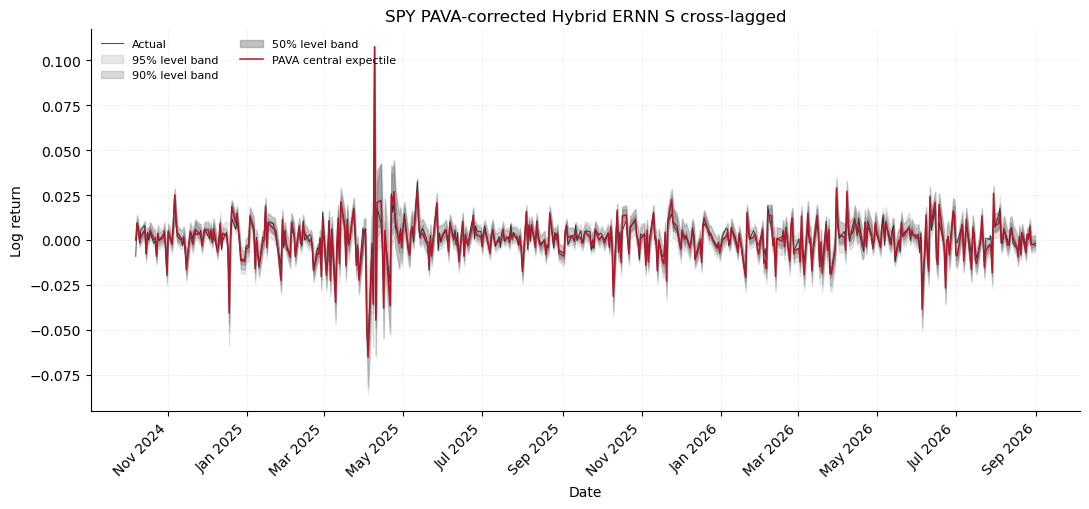

TEST METRICS — PAVA SPY ERNN S CROSS-LAGGED
       tau     raw_nll    pava_nll    raw_ase   pava_ase  raw_hit_rate  pava_hit_rate  mean_absolute_adjustment
0.02500000 -3.79087425 -3.79064750 0.00000221 0.00000222    0.01050420     0.01050420                0.00000069
0.05000000 -3.95501175 -3.98014288 0.00000276 0.00000265    0.08613445     0.08403361                0.00002284
0.25000000 -4.17619670 -4.17668943 0.00000510 0.00000509    0.18487395     0.18907563                0.00002316
0.50000000 -4.15743061 -4.21659939 0.00000700 0.00000596    0.45378151     0.45168067                0.00012396
0.75000000 -3.88060948 -3.91874151 0.00000868 0.00000748    0.68277311     0.69117647                0.00008359
0.95000000 -3.79089149 -3.97499393 0.00000390 0.00000267    0.97899160     0.97899160                0.00079259
0.97500000 -3.67262798 -3.85752457 0.00000281 0.00000174    0.98319328     0.99579832                0.00083618

Raw average NLL:       -3.917663
PAVA average NLL:    -3.98

In [16]:
# ============================================================
# CROSSOVER METHOD: PAVA
# SPY HYBRID ERNN S — CROSS-LAGGED
# Uses saved unrestricted forecasts; no retuning is required
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

LEVELS = np.array([
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975,
], dtype=float)

MODEL_NAME = "spy_ernn_s_cross"
ORIGINAL_DIR = Path("spy_original_tuning_results") / MODEL_NAME
OUTPUT_DIR = Path("spy_pava_crossover_results") / MODEL_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

prediction_path = ORIGINAL_DIR / f"{MODEL_NAME}_test_predictions.csv"
metric_path = ORIGINAL_DIR / f"{MODEL_NAME}_test_metrics.csv"

if not prediction_path.exists() or not metric_path.exists():
    raise FileNotFoundError(
        "Run the original ERNN test-evaluation cell first. "
        "Do not rerun Optuna."
    )

raw_table = pd.read_csv(prediction_path, parse_dates=["Date"])
original_metrics = pd.read_csv(metric_path)
forecast_columns = [f"e_{tau:.3f}" for tau in LEVELS]

missing_columns = [
    name for name in ["Date", "Actual", *forecast_columns]
    if name not in raw_table.columns
]
if missing_columns:
    raise ValueError(
        "Missing prediction columns: " + ", ".join(missing_columns)
    )

raw_forecasts = raw_table[forecast_columns].to_numpy(dtype=float)
actual = raw_table["Actual"].to_numpy(dtype=float)
dates = pd.to_datetime(raw_table["Date"])

sigma_by_level = (
    original_metrics
    .assign(tau=original_metrics["tau"].astype(float))
    .set_index("tau")["Sigma"]
)


def agd_components(y, forecast, sigma, tau):
    sigma = max(float(sigma), np.finfo(float).eps)
    residual = y - forecast
    weight = np.abs(float(tau) - (residual < 0.0).astype(float))
    ase = weight * residual ** 2
    constant = (
        np.log(
            np.sqrt(np.pi / float(tau))
            + np.sqrt(np.pi / (1.0 - float(tau)))
        )
        - np.log(2.0)
    )
    nll = np.log(sigma) + constant + ase / sigma ** 2
    return nll, ase


def crossover_summary(matrix):
    records = []
    total = 0
    tail = 0
    for pair_index in range(len(LEVELS) - 1):
        mask = matrix[:, pair_index] > matrix[:, pair_index + 1]
        count = int(mask.sum())
        is_tail = pair_index in {0, len(LEVELS) - 2}
        total += count
        if is_tail:
            tail += count
        records.append({
            "lower_tau": LEVELS[pair_index],
            "upper_tau": LEVELS[pair_index + 1],
            "violations": count,
            "violation_rate": count / len(matrix),
            "tail_pair": is_tail,
        })
    return total, tail, pd.DataFrame(records)


def equal_weight_pava(values):
    """Least-squares projection onto a nondecreasing sequence."""
    values = np.asarray(values, dtype=float)
    block_values = []
    block_weights = []
    block_starts = []
    block_ends = []

    for index, value in enumerate(values):
        block_values.append(float(value))
        block_weights.append(1.0)
        block_starts.append(index)
        block_ends.append(index)

        while (
            len(block_values) >= 2
            and block_values[-2] > block_values[-1]
        ):
            merged_weight = block_weights[-2] + block_weights[-1]
            merged_value = (
                block_weights[-2] * block_values[-2]
                + block_weights[-1] * block_values[-1]
            ) / merged_weight
            merged_start = block_starts[-2]
            merged_end = block_ends[-1]
            block_values[-2:] = [merged_value]
            block_weights[-2:] = [merged_weight]
            block_starts[-2:] = [merged_start]
            block_ends[-2:] = [merged_end]

    projected = np.empty_like(values, dtype=float)
    for value, start, end in zip(
        block_values, block_starts, block_ends
    ):
        projected[start:end + 1] = value
    return projected


adjusted_forecasts = np.vstack([
    equal_weight_pava(row) for row in raw_forecasts
])


# ------------------------------------------------------------
# Recalculate AGD NLL and ASE after PAVA
# ------------------------------------------------------------

metric_records = []
raw_nll_columns = []
adjusted_nll_columns = []

for level_index, tau in enumerate(LEVELS):
    sigma = float(sigma_by_level.loc[tau])
    raw_value = raw_forecasts[:, level_index]
    adjusted_value = adjusted_forecasts[:, level_index]

    raw_nll, raw_ase = agd_components(
        actual, raw_value, sigma, tau
    )
    adjusted_nll, adjusted_ase = agd_components(
        actual, adjusted_value, sigma, tau
    )

    raw_hit = float(np.mean(actual <= raw_value))
    adjusted_hit = float(np.mean(actual <= adjusted_value))
    raw_nll_columns.append(raw_nll)
    adjusted_nll_columns.append(adjusted_nll)

    metric_records.append({
        "tau": tau,
        "raw_nll": float(np.mean(raw_nll)),
        "pava_nll": float(np.mean(adjusted_nll)),
        "raw_ase": float(np.mean(raw_ase)),
        "pava_ase": float(np.mean(adjusted_ase)),
        "raw_hit_rate": raw_hit,
        "pava_hit_rate": adjusted_hit,
        "mean_absolute_adjustment": float(
            np.mean(np.abs(adjusted_value - raw_value))
        ),
    })

result_metrics = pd.DataFrame(metric_records)
raw_nll_matrix = np.column_stack(raw_nll_columns)
adjusted_nll_matrix = np.column_stack(adjusted_nll_columns)

raw_crossover, raw_tail, raw_crossovers = crossover_summary(
    raw_forecasts
)
adjusted_crossover, adjusted_tail, adjusted_crossovers = (
    crossover_summary(adjusted_forecasts)
)

adjustments = adjusted_forecasts - raw_forecasts
changed_rows = np.any(
    ~np.isclose(adjustments, 0.0, atol=1e-12),
    axis=1,
)


# ------------------------------------------------------------
# Save detailed outputs
# ------------------------------------------------------------

prediction_output = pd.DataFrame({
    "Date": dates,
    "Actual": actual,
})
for level_index, tau in enumerate(LEVELS):
    prediction_output[f"raw_e_{tau:.3f}"] = raw_forecasts[:, level_index]
    prediction_output[f"pava_e_{tau:.3f}"] = (
        adjusted_forecasts[:, level_index]
    )

nll_output = pd.DataFrame({"Date": dates})
for level_index, tau in enumerate(LEVELS):
    nll_output[f"raw_nll_{tau:.3f}"] = raw_nll_matrix[:, level_index]
    nll_output[f"pava_nll_{tau:.3f}"] = (
        adjusted_nll_matrix[:, level_index]
    )
nll_output["raw_average_nll"] = raw_nll_matrix.mean(axis=1)
nll_output["pava_average_nll"] = (
    adjusted_nll_matrix.mean(axis=1)
)

summary = pd.DataFrame([{
    "model": MODEL_NAME,
    "test_T": len(actual),
    "raw_average_nll": result_metrics["raw_nll"].mean(),
    "pava_average_nll": result_metrics["pava_nll"].mean(),
    "raw_average_ase": result_metrics["raw_ase"].mean(),
    "pava_average_ase": result_metrics["pava_ase"].mean(),
    "raw_crossover": raw_crossover,
    "pava_crossover": adjusted_crossover,
    "raw_tail": raw_tail,
    "pava_tail": adjusted_tail,
    "changed_observations": int(changed_rows.sum()),
    "mean_absolute_adjustment": float(np.mean(np.abs(adjustments))),
    "maximum_absolute_adjustment": float(np.max(np.abs(adjustments))),
}])

prefix = "pava_" + MODEL_NAME
prediction_output.to_csv(
    OUTPUT_DIR / f"{prefix}_predictions.csv", index=False
)
result_metrics.to_csv(
    OUTPUT_DIR / f"{prefix}_metrics.csv", index=False
)
nll_output.to_csv(
    OUTPUT_DIR / f"{prefix}_nll_by_date.csv", index=False
)
raw_crossovers.to_csv(
    OUTPUT_DIR / f"{prefix}_raw_crossovers.csv", index=False
)
adjusted_crossovers.to_csv(
    OUTPUT_DIR / f"{prefix}_crossovers.csv", index=False
)
summary.to_csv(
    OUTPUT_DIR / f"{prefix}_summary.csv", index=False
)


# ------------------------------------------------------------
# Plot: black actual, red centre and grey level bands
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.plot(
    dates, actual,
    color="black", linewidth=0.75, alpha=0.70,
    label="Actual",
)
ax.fill_between(
    dates, adjusted_forecasts[:, 0], adjusted_forecasts[:, 6],
    color="grey", alpha=0.18, label="95% level band",
)
ax.fill_between(
    dates, adjusted_forecasts[:, 1], adjusted_forecasts[:, 5],
    color="grey", alpha=0.30, label="90% level band",
)
ax.fill_between(
    dates, adjusted_forecasts[:, 2], adjusted_forecasts[:, 4],
    color="grey", alpha=0.48, label="50% level band",
)
ax.plot(
    dates, adjusted_forecasts[:, 3],
    color="#B2182B", linewidth=1.1,
    label="PAVA central expectile",
)
ax.set(
    title="SPY PAVA-corrected Hybrid ERNN S cross-lagged",
    xlabel="Date",
    ylabel="Log return",
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper left")
fig.tight_layout()

plot_path = OUTPUT_DIR / f"{prefix}_predictions.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()


print("=" * 78)
print("TEST METRICS — PAVA SPY ERNN S CROSS-LAGGED")
print("=" * 78)
print(result_metrics.to_string(index=False, float_format=lambda x: f"{x:.8f}"))
print(f"\nRaw average NLL:       {summary.loc[0, 'raw_average_nll']:.6f}")
print(f"PAVA average NLL:    {summary.loc[0, 'pava_average_nll']:.6f}")
print(f"Raw average ASE:       {summary.loc[0, 'raw_average_ase']:.8f}")
print(f"PAVA average ASE:    {summary.loc[0, 'pava_average_ase']:.8f}")
print(f"Raw crossover:         {raw_crossover}")
print(f"PAVA crossover:      {adjusted_crossover}")
print(f"Raw tail violations:   {raw_tail}")
print(f"PAVA tail violations:{adjusted_tail:>6}")
print(f"Changed observations:  {int(changed_rows.sum())}/{len(actual)}")
print(f"Mean adjustment:       {np.mean(np.abs(adjustments)):.8f}")
print(f"Maximum adjustment:    {np.max(np.abs(adjustments)):.8f}")
print(f"\nPlot saved to:\n{plot_path}")
print(f"\nAll results saved under:\n{OUTPUT_DIR}")


## Crossover - Method 1b


In [19]:
import copy
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ============================================================
# METHOD 1B -- JOINT ERNN S Cross-LAGGED
# Complete-output non-crossing through positive adjacent spacing
# ============================================================

M1B_DISTRIBUTION = 'ernn'   # 'qrnn' or 'ernn'
M1B_FORM = 's'           # 's', 'a', or 'si'
M1B_LAG = 'cross'             # 'self' or 'cross'
M1B_N_TRIALS = 800
M1B_MAX_EPOCHS = 800
M1B_BASE_SEED = 2026

m1b_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
m1b_spacing_names = [
    'delta12', 'delta23', 'delta34',
    'delta45', 'delta56', 'delta67',
]
m1b_model_tag = (
    f'spy_method1b_joint_{M1B_DISTRIBUTION}_{M1B_FORM}_{M1B_LAG}'
)
M1B_OUTPUT_DIR = Path('spy_method1b_results') / m1b_model_tag
M1B_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def m1b_validate_inputs():
    required = ('y_train', 'X_train', 'y_val', 'X_val')
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            'Run the notebook data preparation first. Missing: '
            + ', '.join(missing)
        )

    for y_name, x_name in (
        ('y_train', 'X_train'),
        ('y_val', 'X_val'),
    ):
        y_value = globals()[y_name]
        x_value = globals()[x_name]
        if not isinstance(y_value, torch.Tensor) or not isinstance(
            x_value, torch.Tensor
        ):
            raise TypeError(f'{y_name} and {x_name} must be tensors.')
        if y_value.ndim != 1 or x_value.ndim != 2:
            raise ValueError(f'{y_name} must be (T,) and {x_name} (T,p).')
        if len(y_value) != len(x_value):
            raise ValueError(f'{y_name} and {x_name} lengths differ.')


class Method1BJointHybrid(nn.Module):
    """Central hybrid forecast plus six jointly learned positive gaps."""

    def __init__(self, input_dim, config):
        super().__init__()
        self.eps = 1e-6

        # Identifiable statistical/mixing parameters for the median only.
        self.persistence_raw = nn.Parameter(torch.tensor(1.386))
        self.news1_raw = nn.Parameter(torch.tensor(0.3))
        if M1B_FORM in ('a', 'si'):
            self.news2_raw = nn.Parameter(torch.tensor(0.3))
        self.psi_raw = nn.Parameter(torch.tensor(0.0))

        # One loss scale per final level.
        self.sigma_raw = nn.Parameter(torch.full((7,), 0.5))

        layers = []
        previous_dim = input_dim
        for index in range(config['n_hidden_layers']):
            hidden_dim = config[f'hidden_dim_{index}']
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            previous_dim = hidden_dim

        self.feature_extractor = nn.Sequential(*layers)
        self.median_head = nn.Linear(previous_dim, 1)
        self.spacing_heads = nn.ModuleDict({
            name: nn.Linear(previous_dim + 1, 1)
            for name in m1b_spacing_names
        })

        for module in self.modules():
            if isinstance(module, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    @staticmethod
    def _activation(name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh(),
        }[name]

    def _positive_spacing(self, features, reference, name):
        spacing_input = torch.cat(
            [features, reference.unsqueeze(1)], dim=1
        )
        raw_spacing = self.spacing_heads[name](spacing_input).squeeze(1)
        return F.softplus(raw_spacing) + self.eps

    def _median_recursion(
        self,
        y,
        median_fnn,
        initial_state=None,
        initial_y=None,
    ):
        if (initial_state is None) != (initial_y is None):
            raise ValueError(
                'initial_state and initial_y must be supplied together.'
            )

        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        news2 = (
            F.softplus(self.news2_raw)
            if M1B_FORM in ('a', 'si')
            else None
        )
        psi = torch.sigmoid(self.psi_raw)

        has_state = initial_state is not None
        previous_state = (
            initial_state if has_state else y.new_zeros(())
        )

        statistical_values = []
        hybrid_values = []

        for time_index in range(len(y)):
            if time_index == 0 and not has_state:
                zero = y.new_zeros(())
                statistical_values.append(zero)
                hybrid_values.append(zero)
                continue

            previous_y = (
                initial_y if time_index == 0 else y[time_index - 1]
            )
            if M1B_FORM == 'a':
                positive_return = torch.clamp(previous_y, min=0)
                negative_return = torch.clamp(-previous_y, min=0)
                statistical = (
                    persistence * previous_state
                    + news1 * positive_return
                    + news2 * negative_return
                )
            else:
                absolute_return = torch.abs(previous_y)
                statistical = (
                    persistence * previous_state
                    + news1 * absolute_return
                )
                if M1B_FORM == 'si':
                    statistical = (
                        statistical
                        + news2 * previous_state * absolute_return
                    )

            hybrid = psi * statistical + (1 - psi) * median_fnn[
                time_index
            ]
            statistical_values.append(statistical)
            hybrid_values.append(hybrid)

            previous_state = (
                statistical if M1B_LAG == 'self' else hybrid
            )

        return (
            torch.stack(hybrid_values),
            torch.stack(statistical_values),
        )

    def forward(
        self,
        y,
        X,
        initial_state=None,
        initial_y=None,
    ):
        features = self.feature_extractor(X)
        median_fnn = self.median_head(features).squeeze(1)
        median, statistical = self._median_recursion(
            y,
            median_fnn,
            initial_state=initial_state,
            initial_y=initial_y,
        )

        # Outward reconstruction; references remain attached so that
        # all seven losses jointly train the median and inner spacings.
        delta34 = self._positive_spacing(features, median, 'delta34')
        level3 = median - delta34
        delta23 = self._positive_spacing(features, level3, 'delta23')
        level2 = level3 - delta23
        delta12 = self._positive_spacing(features, level2, 'delta12')
        level1 = level2 - delta12

        delta45 = self._positive_spacing(features, median, 'delta45')
        level5 = median + delta45
        delta56 = self._positive_spacing(features, level5, 'delta56')
        level6 = level5 + delta56
        delta67 = self._positive_spacing(features, level6, 'delta67')
        level7 = level6 + delta67

        forecasts = torch.stack(
            [level1, level2, level3, median, level5, level6, level7],
            dim=1,
        )
        spacings = torch.stack(
            [delta12, delta23, delta34, delta45, delta56, delta67],
            dim=1,
        )
        sigma = F.softplus(self.sigma_raw) + self.eps
        continuation_state = (
            statistical if M1B_LAG == 'self' else median
        )
        return forecasts, sigma, continuation_state, statistical, median, spacings


def m1b_joint_nll(y, forecasts, sigma):
    levels = forecasts.new_tensor(m1b_levels)
    residual = y.unsqueeze(1) - forecasts

    if M1B_DISTRIBUTION == 'qrnn':
        indicator = (residual < 0).to(forecasts.dtype)
        check_loss = residual * (levels.unsqueeze(0) - indicator)
        nll = (
            -torch.log(levels * (1 - levels)).unsqueeze(0)
            + torch.log(sigma).unsqueeze(0)
            + check_loss / sigma.unsqueeze(0)
        )
    else:
        weight = torch.abs(
            levels.unsqueeze(0)
            - (residual < 0).to(forecasts.dtype)
        )
        constant = (
            torch.log(
                torch.sqrt(torch.pi / levels)
                + torch.sqrt(torch.pi / (1 - levels))
            )
            - np.log(2.0)
        )
        nll = (
            torch.log(sigma).unsqueeze(0)
            + constant.unsqueeze(0)
            + weight * residual.square() / sigma.square().unsqueeze(0)
        )

    return nll.mean()


def m1b_secondary_metric(y, forecasts):
    levels = forecasts.new_tensor(m1b_levels)
    if M1B_DISTRIBUTION == 'qrnn':
        hit_rate = (y.unsqueeze(1) <= forecasts).float().mean(dim=0)
        by_level = torch.abs(hit_rate - levels)
        return by_level, by_level.mean(), hit_rate

    residual = y.unsqueeze(1) - forecasts
    weight = torch.abs(
        levels.unsqueeze(0)
        - (residual < 0).to(forecasts.dtype)
    )
    by_level = (weight * residual.square()).mean(dim=0)
    return by_level, by_level.mean(), None


def m1b_crossover(forecasts):
    violations = forecasts[:, :-1] > forecasts[:, 1:]
    pair_counts = violations.sum(dim=0)
    sample_size = forecasts.shape[0]
    total = int(pair_counts.sum().item())
    tail = int(pair_counts[0].item() + pair_counts[-1].item())
    return {
        'pair_counts': [int(value) for value in pair_counts.tolist()],
        'total_count': total,
        'total_rate': total / (sample_size * 6),
        'tail_count': tail,
        'tail_rate': tail / (sample_size * 2),
    }


def m1b_suggest_config(trial):
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation': trial.suggest_categorical(
            'activation', ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm': trial.suggest_categorical(
            'layernorm', [True, False]
        ),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float(
            'weight_decay', 0.0, 1e-4
        ),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical(
            'patience', [10, 20, 30]
        ),
    }
    for index in range(config['n_hidden_layers']):
        config[f'hidden_dim_{index}'] = trial.suggest_int(
            f'hidden_dim_{index}', 32, 256
        )
    return config


def m1b_fit(config, max_epochs=M1B_MAX_EPOCHS, seed=M1B_BASE_SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = Method1BJointHybrid(X_train.shape[1], config)
    optimizer_class = (
        torch.optim.Adam
        if config['optimizer'] == 'adam'
        else torch.optim.AdamW
    )
    optimizer = optimizer_class(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6
    )

    best_loss = float('inf')
    best_state = None
    patience_counter = 0

    for _ in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        train_forecasts, sigma, _, _, _, _ = model(y_train, X_train)
        train_loss = m1b_joint_nll(
            y_train[1:], train_forecasts[1:], sigma
        )
        if not torch.isfinite(train_loss):
            return None
        train_loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(), config['gradient_clip']
        )
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, _, train_state, _, _, _ = model(y_train, X_train)
            validation_forecasts, validation_sigma, _, _, _, _ = model(
                y_val,
                X_val,
                initial_state=train_state[-1],
                initial_y=y_train[-1],
            )
            validation_loss = m1b_joint_nll(
                y_val, validation_forecasts, validation_sigma
            )

        if not torch.isfinite(validation_loss):
            return None
        scheduler.step(validation_loss.item())
        if validation_loss.item() < best_loss:
            best_loss = validation_loss.item()
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def m1b_evaluate(model):
    model.eval()
    with torch.no_grad():
        _, _, train_state, _, _, _ = model(y_train, X_train)
        forecasts, sigma, _, _, _, spacings = model(
            y_val,
            X_val,
            initial_state=train_state[-1],
            initial_y=y_train[-1],
        )
        mean_nll = m1b_joint_nll(y_val, forecasts, sigma).item()
        by_level, secondary, hit_rate = m1b_secondary_metric(
            y_val, forecasts
        )

        metrics = {
            'mean_nll': mean_nll,
            'secondary': secondary.item(),
            'secondary_by_level': by_level.tolist(),
            'crossover': m1b_crossover(forecasts),
            'spacing_mean': spacings.mean(dim=0).tolist(),
            'spacing_min': spacings.min(dim=0).values.tolist(),
            'spacing_max': spacings.max(dim=0).values.tolist(),
            'spacing_std': spacings.std(
                dim=0, unbiased=False
            ).tolist(),
            'near_zero_count': (
                spacings <= 1e-5
            ).sum(dim=0).tolist(),
            'persistence': torch.sigmoid(
                model.persistence_raw
            ).item(),
            'news1': F.softplus(model.news1_raw).item(),
            'news2': (
                F.softplus(model.news2_raw).item()
                if M1B_FORM in ('a', 'si')
                else np.nan
            ),
            'psi': torch.sigmoid(model.psi_raw).item(),
            'sigma': (
                F.softplus(model.sigma_raw) + model.eps
            ).tolist(),
        }
        if hit_rate is not None:
            metrics['hit_rate'] = hit_rate.tolist()
        return metrics


def m1b_objective(trial):
    config = m1b_suggest_config(trial)
    model = m1b_fit(config)
    if model is None:
        return float('inf')
    metrics = m1b_evaluate(model)
    for name, value in metrics.items():
        trial.set_user_attr(name, value)
    metric_name = 'HRE' if M1B_DISTRIBUTION == 'qrnn' else 'ASE'
    print(
        f"Trial {trial.number}: NLL={metrics['mean_nll']:.6f} | "
        f"{metric_name}={metrics['secondary']:.8f} | "
        f"crossover={metrics['crossover']['total_rate']:.2%}"
    )
    return metrics['mean_nll']


def m1b_select_by_rank(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and 'mean_nll' in trial.user_attrs
        and 'secondary' in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError('No valid Method 1b trials.')

    nll_order = sorted(
        trials,
        key=lambda trial: (trial.user_attrs['mean_nll'], trial.number),
    )
    secondary_order = sorted(
        trials,
        key=lambda trial: (trial.user_attrs['secondary'], trial.number),
    )
    rank_nll = {
        trial.number: rank
        for rank, trial in enumerate(nll_order, 1)
    }
    rank_secondary = {
        trial.number: rank
        for rank, trial in enumerate(secondary_order, 1)
    }
    best = min(
        trials,
        key=lambda trial: (
            rank_nll[trial.number] + rank_secondary[trial.number],
            trial.user_attrs['mean_nll'],
            trial.user_attrs['secondary'],
            trial.number,
        ),
    )
    return best, trials, rank_nll, rank_secondary


m1b_validate_inputs()
print('\n' + '=' * 72)
print(
    f'Tuning Method 1b Joint {M1B_DISTRIBUTION.upper()} '
    f'{M1B_FORM.upper()} {M1B_LAG.title()}-lagged'
)
print('=' * 72)

m1b_study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=M1B_BASE_SEED),
)
m1b_study.optimize(
    m1b_objective,
    n_trials=M1B_N_TRIALS,
    show_progress_bar=True,
    gc_after_trial=True,
)

(
    m1b_best_trial,
    m1b_all_trials,
    m1b_rank_nll,
    m1b_rank_secondary,
) = m1b_select_by_rank(m1b_study)

m1b_ranking_records = []
for trial in m1b_all_trials:
    record = {
        'trial': trial.number,
        'mean_nll': trial.user_attrs['mean_nll'],
        ('mean_hre' if M1B_DISTRIBUTION == 'qrnn' else 'mean_ase'):
            trial.user_attrs['secondary'],
        'rank_nll': m1b_rank_nll[trial.number],
        'rank_secondary': m1b_rank_secondary[trial.number],
        'sum_rank': (
            m1b_rank_nll[trial.number]
            + m1b_rank_secondary[trial.number]
        ),
        'crossover_count': trial.user_attrs['crossover']['total_count'],
        'crossover_rate': trial.user_attrs['crossover']['total_rate'],
        'tail_count': trial.user_attrs['crossover']['tail_count'],
        'tail_rate': trial.user_attrs['crossover']['tail_rate'],
        'persistence': trial.user_attrs['persistence'],
        'news1': trial.user_attrs['news1'],
        'news2': trial.user_attrs['news2'],
        'psi': trial.user_attrs['psi'],
    }
    for index, level in enumerate(m1b_levels):
        metric_label = 'hre' if M1B_DISTRIBUTION == 'qrnn' else 'ase'
        record[f'{metric_label}_{level:.3f}'] = trial.user_attrs[
            'secondary_by_level'
        ][index]
        record[f'sigma_{level:.3f}'] = trial.user_attrs['sigma'][index]
    record.update(trial.params)
    m1b_ranking_records.append(record)

m1b_ranking_df = pd.DataFrame(m1b_ranking_records).sort_values(
    ['sum_rank', 'mean_nll', 'trial']
)
m1b_ranking_filename = (
    M1B_OUTPUT_DIR / f'{m1b_model_tag}_ranking.csv'
)
m1b_ranking_df.to_csv(m1b_ranking_filename, index=False)

m1b_best_config = m1b_best_trial.params.copy()
m1b_best_model = m1b_fit(m1b_best_config)
if m1b_best_model is None:
    raise RuntimeError('Selected Method 1b configuration failed to refit.')
m1b_best_metrics = m1b_evaluate(m1b_best_model)

m1b_checkpoint_filename = (
    M1B_OUTPUT_DIR / f'{m1b_model_tag}_best.pt'
)
torch.save(
    {
        'model_state_dict': m1b_best_model.state_dict(),
        'asset': 'SPY',
        'selected_trial': m1b_best_trial.number,
        'config': m1b_best_config,
        'levels': m1b_levels,
        'distribution': M1B_DISTRIBUTION,
        'form': M1B_FORM,
        'lag': M1B_LAG,
        'validation_metrics': m1b_best_metrics,
    },
    m1b_checkpoint_filename,
)

m1b_metric_name = 'HRE' if M1B_DISTRIBUTION == 'qrnn' else 'ASE'
print('\n' + '=' * 72)
print('METHOD 1B TUNING COMPLETE')
print('=' * 72)
print(f'Best trial: #{m1b_best_trial.number}')
print(f"Mean validation NLL: {m1b_best_metrics['mean_nll']:.6f}")
print(
    f"Mean validation {m1b_metric_name}: "
    f"{m1b_best_metrics['secondary']:.8f}"
)
print(
    f"Final crossover: {m1b_best_metrics['crossover']['total_count']} "
    f"({m1b_best_metrics['crossover']['total_rate']:.2%})"
)
print(f'Saved ranking: {m1b_ranking_filename}')
print(f'Saved model: {m1b_checkpoint_filename}')



[I 2026-09-23 09:44:03,774] A new study created in memory with name: no-name-af7ca853-8ecb-458f-a51b-0115216f7ab9



Tuning Method 1b Joint ERNN S Cross-lagged


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: NLL=0.993105 | ASE=0.00117091 | crossover=0.00%
[I 2026-09-23 09:45:44,570] Trial 0 finished with value: 0.9931047558784485 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 0.9931047558784485.
Trial 1: NLL=-3.494836 | ASE=0.00000267 | crossover=0.00%
[I 2026-09-23 09:47:28,032] Trial 1 finished with value: -3.494835615158081 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -3.494835615158081.
Trial 2: NLL=1.320841 | ASE=0.00115602 | crossover=0.00%
[I 2026-09-23 09:

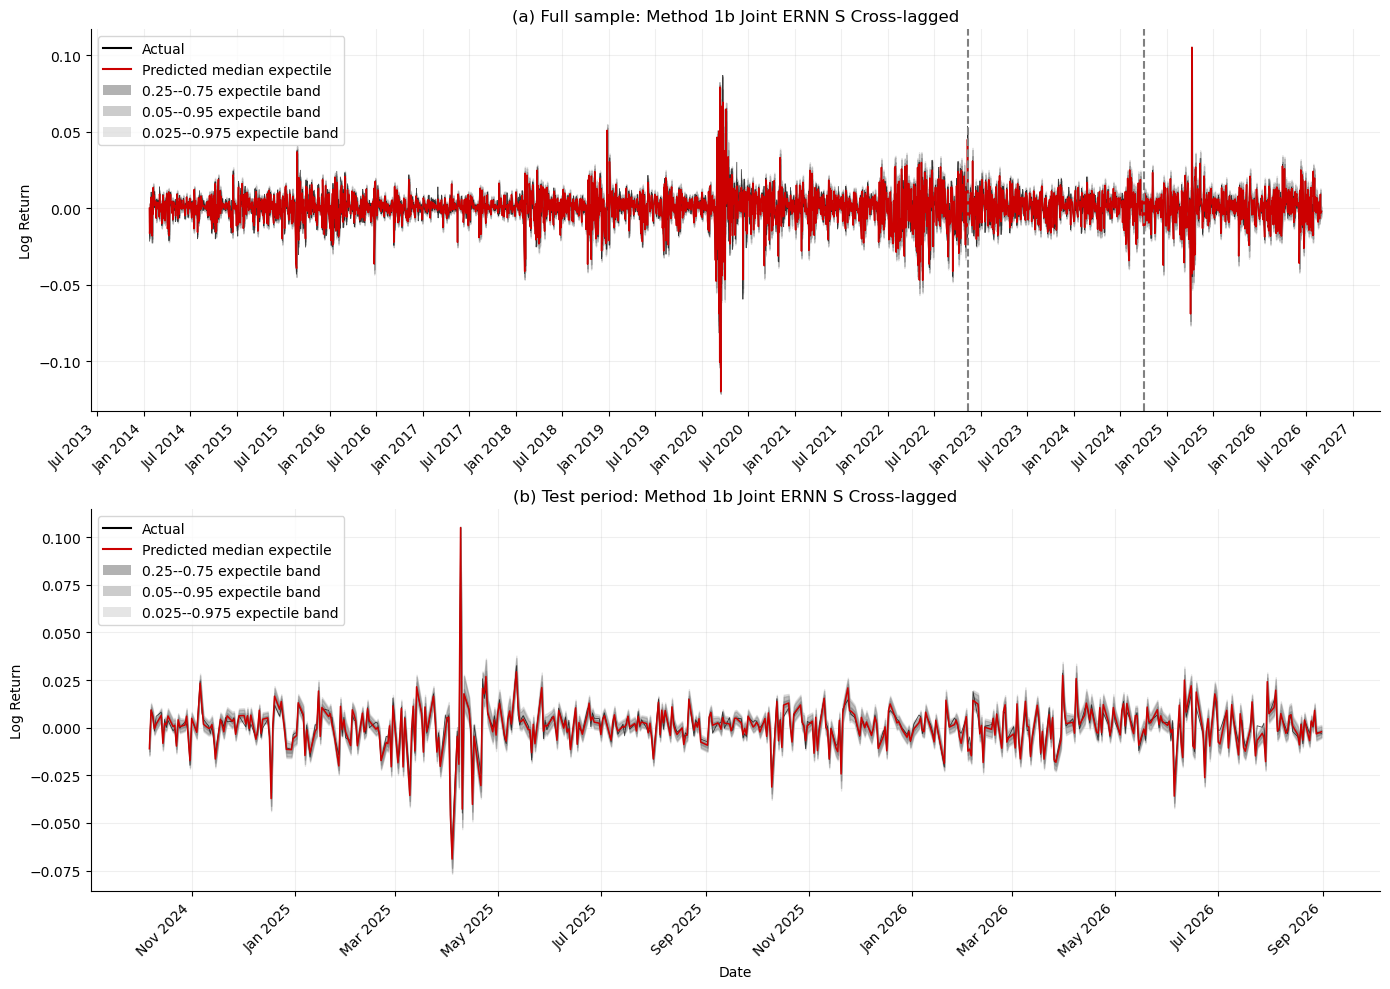

Plot saved to: spy_method1b_results/spy_method1b_joint_ernn_s_cross/spy_method1b_joint_ernn_s_cross_predictions.png

TEST METRICS -- METHOD 1B JOINT ERNN S CROSS-LAGGED
 level       NLL          ASE    sigma
 0.025 -4.192903 9.764369e-07 0.001533
 0.050 -4.246219 1.569179e-06 0.001919
 0.250 -4.325114 4.092240e-06 0.003036
 0.500 -4.383673 4.433528e-06 0.003368
 0.750 -4.285092 4.447141e-06 0.003115
 0.950 -4.186253 1.764894e-06 0.002051
 0.975 -4.100808 1.178137e-06 0.001665

Average NLL: -4.245723
Average ASE: 0.00000264

CROSSOVER ANALYSIS -- FINAL METHOD 1B FORECASTS
 Lower  Upper  Violations  Rate
 0.025  0.050           0   0.0
 0.050  0.250           0   0.0
 0.250  0.500           0   0.0
 0.500  0.750           0   0.0
 0.750  0.950           0   0.0
 0.950  0.975           0   0.0

Total violations: 0
Tail violations: 0

LEARNED SPACING DIAGNOSTICS -- TEST PERIOD
Spacing  Lower_Level  Upper_Level  Mean_Delta  Minimum_Delta  Maximum_Delta  Delta_Std  Near_Zero_Count  Near_Zero

In [21]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# PLOT AND EVALUATE METHOD 1B -- ERNN S
# Cross-LAGGED
# ============================================================

m1b_plot_pairs = list(zip(m1b_levels[:-1], m1b_levels[1:]))
m1b_plot_tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

if 'm1b_best_model' not in globals():
    m1b_plot_checkpoint_filename = (
        M1B_OUTPUT_DIR / f'{m1b_model_tag}_best.pt'
    )
    m1b_plot_checkpoint = torch.load(
        m1b_plot_checkpoint_filename,
        map_location='cpu',
        weights_only=False,
    )
    m1b_best_model = Method1BJointHybrid(
        X_train.shape[1], m1b_plot_checkpoint['config']
    )
    m1b_best_model.load_state_dict(
        m1b_plot_checkpoint['model_state_dict']
    )

m1b_best_model.eval()

m1b_plot_X_all = torch.tensor(
    df[feature_cols].values, dtype=torch.float32
)
m1b_plot_y_all = torch.tensor(
    df['log_return'].values, dtype=torch.float32
)

with torch.no_grad():
    (
        m1b_plot_forecasts_all,
        m1b_plot_sigma,
        _,
        _,
        _,
        m1b_plot_spacings_all,
    ) = m1b_best_model(m1b_plot_y_all, m1b_plot_X_all)

m1b_plot_forecasts_np = m1b_plot_forecasts_all.cpu().numpy()
m1b_plot_spacings_np = m1b_plot_spacings_all.cpu().numpy()
m1b_plot_test_start = len(train_df) + len(val_df)
m1b_plot_forecasts_test = m1b_plot_forecasts_all[
    m1b_plot_test_start:
]
m1b_plot_spacings_test = m1b_plot_spacings_all[m1b_plot_test_start:]
m1b_plot_y_test = m1b_plot_y_all[m1b_plot_test_start:]

if len(m1b_plot_forecasts_test) != len(test_df):
    raise ValueError(
        'Test forecast length does not match test_df. Check the split.'
    )


def m1b_draw_panel(axis, dates, actual, forecasts):
    axis.plot(dates, actual, color='#000000', linewidth=0.6, alpha=0.7)
    axis.plot(
        dates, forecasts[:, 3], color='#CC0000', linewidth=1.1
    )
    axis.fill_between(
        dates, forecasts[:, 0], forecasts[:, 6],
        color='#808080', alpha=0.20,
    )
    axis.fill_between(
        dates, forecasts[:, 1], forecasts[:, 5],
        color='#808080', alpha=0.40,
    )
    axis.fill_between(
        dates, forecasts[:, 2], forecasts[:, 4],
        color='#808080', alpha=0.60,
    )
    axis.set_ylabel('Log Return')
    axis.grid(True, alpha=0.2)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)


m1b_plot_distribution_label = M1B_DISTRIBUTION.upper()
m1b_plot_form_label = M1B_FORM.upper()
m1b_plot_lag_label = M1B_LAG.title()
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

m1b_draw_panel(
    axes[0], df.index, df['log_return'].values, m1b_plot_forecasts_np
)
axes[0].axvline(train_df.index[-1], color='gray', linestyle='--')
axes[0].axvline(val_df.index[-1], color='gray', linestyle='--')
axes[0].set_title(
    f'(a) Full sample: Method 1b Joint {m1b_plot_distribution_label} '
    f'{m1b_plot_form_label} {m1b_plot_lag_label}-lagged'
)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))

m1b_draw_panel(
    axes[1],
    test_df.index,
    test_df['log_return'].values,
    m1b_plot_forecasts_np[m1b_plot_test_start:],
)
axes[1].set_title(
    f'(b) Test period: Method 1b Joint '
    f'{m1b_plot_distribution_label} {m1b_plot_form_label} '
    f'{m1b_plot_lag_label}-lagged'
)
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

if M1B_DISTRIBUTION == 'qrnn':
    median_label = 'Predicted Median (Q50)'
    band_labels = ['50% PI', '90% PI', '95% PI']
else:
    median_label = 'Predicted median expectile'
    band_labels = [
        '0.25--0.75 expectile band',
        '0.05--0.95 expectile band',
        '0.025--0.975 expectile band',
    ]

m1b_legend = [
    Line2D([0], [0], color='#000000', label='Actual'),
    Line2D([0], [0], color='#CC0000', label=median_label),
    Patch(facecolor='#808080', alpha=0.60, label=band_labels[0]),
    Patch(facecolor='#808080', alpha=0.40, label=band_labels[1]),
    Patch(facecolor='#808080', alpha=0.20, label=band_labels[2]),
]
for axis in axes:
    axis.legend(handles=m1b_legend, loc='upper left')
    plt.setp(
        axis.xaxis.get_majorticklabels(), rotation=45, ha='right'
    )

plt.tight_layout()
m1b_plot_png = (
    M1B_OUTPUT_DIR / f'{m1b_model_tag}_predictions.png'
)
plt.savefig(m1b_plot_png, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f'Plot saved to: {m1b_plot_png}')


# ============================================================
# Test metrics by level
# ============================================================

m1b_plot_metric_rows = []
m1b_plot_nll_columns = []
for index, level in enumerate(m1b_levels):
    forecast = m1b_plot_forecasts_test[:, index]
    sigma = m1b_plot_sigma[index]
    residual = m1b_plot_y_test - forecast

    if M1B_DISTRIBUTION == 'qrnn':
        indicator = (residual < 0).to(residual.dtype)
        check_loss = residual * (level - indicator)
        nll_by_observation = (
            -torch.log(residual.new_tensor(level * (1 - level)))
            + torch.log(sigma)
            + check_loss / sigma
        )
        nll = nll_by_observation.mean().item()
        m1b_plot_nll_columns.append(
            nll_by_observation.detach().cpu().numpy()
        )
        hit_rate = (
            m1b_plot_y_test <= forecast
        ).float().mean().item()
        secondary = abs(hit_rate - level)
        row = {
            'level': level,
            'NLL': nll,
            'Hit_Rate': hit_rate,
            'HRE': secondary,
            'sigma': sigma.item(),
        }
    else:
        weight = torch.abs(
            residual.new_tensor(level)
            - (residual < 0).to(residual.dtype)
        )
        weighted_squared_error = weight * residual.square()
        constant = (
            torch.log(
                torch.sqrt(residual.new_tensor(torch.pi / level))
                + torch.sqrt(
                    residual.new_tensor(torch.pi / (1 - level))
                )
            )
            - np.log(2.0)
        )
        nll_by_observation = (
            torch.log(sigma)
            + constant
            + weighted_squared_error / sigma.square()
        )
        nll = nll_by_observation.mean().item()
        m1b_plot_nll_columns.append(
            nll_by_observation.detach().cpu().numpy()
        )
        secondary = weighted_squared_error.mean().item()
        row = {
            'level': level,
            'NLL': nll,
            'ASE': secondary,
            'sigma': sigma.item(),
        }

    m1b_plot_metric_rows.append(row)

m1b_plot_metrics_df = pd.DataFrame(m1b_plot_metric_rows)
m1b_plot_metric_column = (
    'HRE' if M1B_DISTRIBUTION == 'qrnn' else 'ASE'
)
print('\n' + '=' * 72)
print(
    f'TEST METRICS -- METHOD 1B JOINT '
    f'{m1b_plot_distribution_label} {m1b_plot_form_label} '
    f'{m1b_plot_lag_label.upper()}-LAGGED'
)
print('=' * 72)
print(m1b_plot_metrics_df.to_string(index=False))
print(f"\nAverage NLL: {m1b_plot_metrics_df['NLL'].mean():.6f}")
print(
    f'Average {m1b_plot_metric_column}: '
    f"{m1b_plot_metrics_df[m1b_plot_metric_column].mean():.8f}"
)


# ============================================================
# Crossover and learned-spacing diagnostics
# ============================================================

m1b_plot_crossover_rows = []
for index, (lower, upper) in enumerate(m1b_plot_pairs):
    count = int((
        m1b_plot_forecasts_test[:, index]
        > m1b_plot_forecasts_test[:, index + 1]
    ).sum().item())
    m1b_plot_crossover_rows.append({
        'Lower': lower,
        'Upper': upper,
        'Violations': count,
        'Rate': count / len(m1b_plot_y_test),
    })

m1b_plot_crossover_df = pd.DataFrame(m1b_plot_crossover_rows)
m1b_plot_total = int(m1b_plot_crossover_df['Violations'].sum())
m1b_plot_tail = int(
    m1b_plot_crossover_df.iloc[0]['Violations']
    + m1b_plot_crossover_df.iloc[-1]['Violations']
)
print('\n' + '=' * 72)
print('CROSSOVER ANALYSIS -- FINAL METHOD 1B FORECASTS')
print('=' * 72)
print(m1b_plot_crossover_df.to_string(index=False))
print(f'\nTotal violations: {m1b_plot_total}')
print(f'Tail violations: {m1b_plot_tail}')

m1b_plot_spacing_rows = []
for index, (name, pair) in enumerate(zip(
    m1b_spacing_names, m1b_plot_pairs
)):
    spacing = m1b_plot_spacings_test[:, index]
    m1b_plot_spacing_rows.append({
        'Spacing': name,
        'Lower_Level': pair[0],
        'Upper_Level': pair[1],
        'Mean_Delta': spacing.mean().item(),
        'Minimum_Delta': spacing.min().item(),
        'Maximum_Delta': spacing.max().item(),
        'Delta_Std': spacing.std(unbiased=False).item(),
        'Near_Zero_Count': int((spacing <= 1e-5).sum().item()),
        'Near_Zero_Rate': (
            spacing <= 1e-5
        ).float().mean().item(),
    })

m1b_plot_spacing_df = pd.DataFrame(m1b_plot_spacing_rows)
print('\n' + '=' * 72)
print('LEARNED SPACING DIAGNOSTICS -- TEST PERIOD')
print('=' * 72)
print(m1b_plot_spacing_df.to_string(index=False))


# ============================================================
# Detailed predictions and saved outputs
# ============================================================

m1b_plot_predictions_df = pd.DataFrame({
    'Date': pd.to_datetime(test_df.index),
    'Actual': test_df['log_return'].values,
})
m1b_plot_prefix = 'Q' if M1B_DISTRIBUTION == 'qrnn' else 'E'
for index, level in enumerate(m1b_levels):
    m1b_plot_predictions_df[f'{m1b_plot_prefix}_{level:.3f}'] = (
        m1b_plot_forecasts_np[m1b_plot_test_start:, index]
    )
for index, (lower, upper) in enumerate(m1b_plot_pairs):
    m1b_plot_predictions_df[
        f'Gap_{lower:.3f}_{upper:.3f}'
    ] = m1b_plot_spacings_np[m1b_plot_test_start:, index]

m1b_plot_nll_df = pd.DataFrame({
    'Date': pd.to_datetime(test_df.index),
})
for index, level in enumerate(m1b_levels):
    m1b_plot_nll_df[f'nll_{level:.3f}'] = m1b_plot_nll_columns[index]
m1b_plot_nll_df['average_nll'] = np.column_stack(
    m1b_plot_nll_columns
).mean(axis=1)

m1b_plot_metrics_file = M1B_OUTPUT_DIR / f'{m1b_model_tag}_test_metrics.csv'
m1b_plot_crossover_file = M1B_OUTPUT_DIR / f'{m1b_model_tag}_crossover.csv'
m1b_plot_spacing_file = M1B_OUTPUT_DIR / f'{m1b_model_tag}_delta_summary.csv'
m1b_plot_predictions_file = M1B_OUTPUT_DIR / f'{m1b_model_tag}_test_predictions.csv'
m1b_plot_nll_file = M1B_OUTPUT_DIR / f'{m1b_model_tag}_test_nll_by_date.csv'

m1b_plot_metrics_df.to_csv(m1b_plot_metrics_file, index=False)
m1b_plot_crossover_df.to_csv(m1b_plot_crossover_file, index=False)
m1b_plot_spacing_df.to_csv(m1b_plot_spacing_file, index=False)
m1b_plot_predictions_df.to_csv(m1b_plot_predictions_file, index=False)
m1b_plot_nll_df.to_csv(m1b_plot_nll_file, index=False)

print('\nSaved Method 1b outputs:')
for filename in (
    m1b_plot_png,
    m1b_plot_metrics_file,
    m1b_plot_crossover_file,
    m1b_plot_spacing_file,
    m1b_plot_predictions_file,
    m1b_plot_nll_file,
):
    print(f'  {filename}')



## Crossover - Method 3

Sequential learned positive adjacent spacing. Run the tuning cell first and then the plotting/test cell.


In [24]:
"""Method 3, Specification 1: Hybrid ERNN S cross-lagged.

Run this after the notebook has created the four tensors
``y_train``, ``X_train``, ``y_val`` and ``X_val``.

The median is the corresponding original hybrid model.  Every non-median
network predicts a raw adjacent gap; ``softplus`` makes that gap positive and
the target level is reconstructed from its already-fitted adjacent reference.
There is no fixed epsilon boundary, max/min projection, or crossover penalty.
"""

from __future__ import annotations

import copy
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ---------------------------------------------------------------------------
# User settings
# ---------------------------------------------------------------------------

LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ESTIMATION_ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE_LEVEL = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

N_TRIALS = 200
MAX_EPOCHS = 200
BASE_SEED = 2026
PSI_MARGIN = 1e-4
INITIAL_DELTA_BIAS = -4.6  # softplus(-4.6) is about 0.01; trainable.
OUTPUT_DIR = Path("spy_method3_spacing_ernn_s_cross_results")

# This standalone chunk estimates only the model supplied by the user:
# SPY Hybrid ERNN, S form, cross-lagged recursion.
MODELS_TO_RUN = [("ernn", "s", "cross")]


def validate_notebook_inputs():
    required = ("y_train", "X_train", "y_val", "X_val")
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            "Create these notebook tensors before running Method 3: "
            + ", ".join(missing)
        )
    for y_name, x_name in (("y_train", "X_train"), ("y_val", "X_val")):
        y_value, x_value = globals()[y_name], globals()[x_name]
        if not isinstance(y_value, torch.Tensor) or not isinstance(x_value, torch.Tensor):
            raise TypeError(f"{y_name} and {x_name} must be torch tensors.")
        if y_value.ndim != 1 or x_value.ndim != 2 or len(y_value) != len(x_value):
            raise ValueError(f"{y_name} must be (T,) and {x_name} must be (T,p).")


# ---------------------------------------------------------------------------
# Generic Method 3 model
# ---------------------------------------------------------------------------

class Method3SpacingModel(nn.Module):
    """One sequential level model.

    direction=None is the median hybrid model.  Otherwise the network is a
    pure learned-spacing model and deliberately has no redundant statistical
    or mixing parameters.
    """

    def __init__(self, input_dim, config, distribution, form, lag, direction=None):
        super().__init__()
        if distribution not in {"qrnn", "ernn"}:
            raise ValueError("distribution must be 'qrnn' or 'ernn'.")
        if form not in {"s", "a", "si"}:
            raise ValueError("form must be 's', 'a', or 'si'.")
        if lag not in {"self", "cross"}:
            raise ValueError("lag must be 'self' or 'cross'.")

        self.distribution = distribution
        self.form = form
        self.lag = lag
        self.direction = direction

        # Statistical and mixing parameters are identifiable only for median.
        if direction is None:
            self.persistence_raw = nn.Parameter(torch.tensor(1.386))
            self.news1_raw = nn.Parameter(torch.tensor(0.3))
            if form in {"a", "si"}:
                self.news2_raw = nn.Parameter(torch.tensor(0.3))
            self.psi_raw = nn.Parameter(torch.tensor(0.0))

        self.sigma_raw = nn.Parameter(torch.tensor(0.5))
        fnn_input_dim = input_dim if direction is None else input_dim + 1
        layers = []
        previous_dim = fnn_input_dim
        for index in range(config["n_hidden_layers"]):
            hidden_dim = config[f"hidden_dim_{index}"]
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._activation(config["activation"]))
            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.fnn = nn.Sequential(*layers)
        self._initialise_fnn(config["weight_init"])

        if direction is not None:
            nn.init.constant_(self.fnn[-1].bias, INITIAL_DELTA_BIAS)

    @staticmethod
    def _activation(name):
        return {
            "relu": nn.ReLU(),
            "elu": nn.ELU(),
            "gelu": nn.GELU(),
            "tanh": nn.Tanh(),
        }[name]

    def _initialise_fnn(self, method):
        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if method == "glorot":
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def _statistical_update(self, previous_state, previous_y):
        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        if self.form == "s":
            return persistence * previous_state + news1 * torch.abs(previous_y)
        if self.form == "a":
            news2 = F.softplus(self.news2_raw)
            return (
                persistence * previous_state
                + news1 * torch.clamp(previous_y, min=0)
                + news2 * torch.clamp(-previous_y, min=0)
            )
        news2 = F.softplus(self.news2_raw)
        absolute_y = torch.abs(previous_y)
        return (
            persistence * previous_state
            + news1 * absolute_y
            + news2 * previous_state * absolute_y
        )

    def forward(self, y, X, q_reference=None, initial_state=None, initial_y=None):
        sigma = F.softplus(self.sigma_raw) + 1e-6

        # Six non-median models: directly learn a positive adjacent spacing.
        if self.direction is not None:
            if q_reference is None:
                raise ValueError("Non-median levels require q_reference.")
            reference = q_reference.detach()
            raw_delta = self.fnn(
                torch.cat((X, reference.unsqueeze(1)), dim=1)
            ).squeeze(-1)
            delta = F.softplus(raw_delta)
            prediction = reference + delta if self.direction == "upper" else reference - delta
            return prediction, torch.zeros_like(prediction), raw_delta, delta, sigma

        # Median: original hybrid statistical-neural specification.
        if (initial_state is None) != (initial_y is None):
            raise ValueError("initial_state and initial_y must be supplied together.")
        has_initial_state = initial_state is not None
        previous_state = initial_state if has_initial_state else y.new_zeros(())
        fnn_median = self.fnn(X).squeeze(-1)
        psi = (1.0 - PSI_MARGIN) * torch.sigmoid(self.psi_raw)
        predictions, statistical_outputs = [], []

        for t in range(len(y)):
            if t == 0 and not has_initial_state:
                statistical_t = y.new_zeros(())
                hybrid_t = y.new_zeros(())
            else:
                previous_y = initial_y if t == 0 else y[t - 1]
                statistical_t = self._statistical_update(previous_state, previous_y)
                hybrid_t = psi * statistical_t + (1.0 - psi) * fnn_median[t]
            statistical_outputs.append(statistical_t)
            predictions.append(hybrid_t)
            # Settled convention used by the earlier code:
            # self -> previous pure statistical output; cross -> previous hybrid.
            previous_state = statistical_t if self.lag == "self" else hybrid_t

        prediction = torch.stack(predictions)
        statistical = torch.stack(statistical_outputs)
        return prediction, statistical, fnn_median, None, sigma


# ---------------------------------------------------------------------------
# Distribution-specific objectives and calibration metrics
# ---------------------------------------------------------------------------

def single_level_nll(y, location, sigma, level, distribution):
    residual = y - location
    level_tensor = torch.tensor(level, dtype=y.dtype, device=y.device)
    if distribution == "qrnn":
        indicator = (residual < 0).to(y.dtype)
        rho = residual * (level_tensor - indicator)
        return (
            -torch.log(level_tensor * (1.0 - level_tensor))
            + torch.log(sigma)
            + rho / sigma
        ).mean()

    weight = torch.abs(level_tensor - (residual < 0).to(y.dtype))
    omega = weight * residual.square()
    constant = (
        torch.log(
            torch.sqrt(torch.pi / level_tensor)
            + torch.sqrt(torch.pi / (1.0 - level_tensor))
        )
        - np.log(2.0)
    )
    return (torch.log(sigma) + constant + omega / sigma.square()).mean()


def qrnn_calibration(y, location, level):
    if level <= 0.5:
        empirical = (y <= location).float().mean().item()
        target = level
    else:
        empirical = (y > location).float().mean().item()
        target = 1.0 - level
    crp = empirical / target
    return {"hit_rate": (y <= location).float().mean().item(),
            "hre": abs((y <= location).float().mean().item() - level),
            "calibration": crp,
            "calibration_penalty": (crp - 1.0) ** 2}


def ernn_calibration(y, location, level):
    residual = y - location
    weights = torch.where(
        residual >= 0,
        torch.full_like(residual, level),
        torch.full_like(residual, 1.0 - level),
    )
    ase = (weights * residual.square()).mean().item()
    return {"ase": ase, "calibration": ase, "calibration_penalty": ase}


# ---------------------------------------------------------------------------
# Tuning helpers
# ---------------------------------------------------------------------------

def suggest_config(trial):
    config = {
        "n_hidden_layers": trial.suggest_int("n_hidden_layers", 1, 3),
        "activation": trial.suggest_categorical("activation", ["relu", "elu", "gelu", "tanh"]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "layernorm": trial.suggest_categorical("layernorm", [True, False]),
        "weight_init": trial.suggest_categorical("weight_init", ["glorot", "he"]),
        "lr": trial.suggest_float("lr", 1e-4, 5e-2, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw"]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 1e-4),
        "gradient_clip": trial.suggest_categorical("gradient_clip", [0.1, 1.0, 5.0]),
        "patience": trial.suggest_categorical("patience", [10, 20, 30]),
    }
    for index in range(config["n_hidden_layers"]):
        config[f"hidden_dim_{index}"] = trial.suggest_int(f"hidden_dim_{index}", 32, 256)
    return config


def make_optimizer(model, config):
    optimizer_class = torch.optim.Adam if config["optimizer"] == "adam" else torch.optim.AdamW
    return optimizer_class(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])


def median_validation_state(model, statistical_train, prediction_train):
    return statistical_train[-1] if model.lag == "self" else prediction_train[-1]


def predict_train_val(model, direction, q_reference_train=None, q_reference_val=None):
    model.eval()
    with torch.no_grad():
        q_train, stat_train, _, delta_train, _ = model(
            y_train, X_train, q_reference_train
        )
        if direction is None:
            q_val, _, _, delta_val, sigma = model(
                y_val,
                X_val,
                initial_state=median_validation_state(model, stat_train, q_train),
                initial_y=y_train[-1],
            )
        else:
            q_val, _, _, delta_val, sigma = model(y_val, X_val, q_reference_val)
    return q_train.detach(), q_val.detach(), delta_train, delta_val, sigma.detach()


def train_config(spec, config, level, direction, q_ref_train, q_ref_val, seed):
    distribution, form, lag = spec
    torch.manual_seed(seed)
    model = Method3SpacingModel(
        X_train.shape[1], config, distribution, form, lag, direction
    )
    optimizer = make_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=10, factor=0.5, min_lr=1e-6
    )
    best_loss, counter, best_state = float("inf"), 0, None

    for _ in range(MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()
        q_train, _, _, _, sigma = model(y_train, X_train, q_ref_train)
        loss = single_level_nll(y_train[1:], q_train[1:], sigma, level, distribution)
        if not torch.isfinite(loss):
            return None
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clip"])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, q_val, _, _, sigma_val = predict_train_val(
                model, direction, q_ref_train, q_ref_val
            )
            val_loss = single_level_nll(y_val, q_val, sigma_val, level, distribution)
        scheduler.step(val_loss.item())
        if val_loss.item() < best_loss:
            best_loss, counter = val_loss.item(), 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= config["patience"]:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def transformed_median_parameters(model):
    if model.direction is not None:
        return {}
    result = {
        "persistence": torch.sigmoid(model.persistence_raw).item(),
        "news1": F.softplus(model.news1_raw).item(),
        "psi": ((1.0 - PSI_MARGIN) * torch.sigmoid(model.psi_raw)).item(),
    }
    result["news2"] = (
        F.softplus(model.news2_raw).item() if hasattr(model, "news2_raw") else np.nan
    )
    return result


def evaluate(model, level, direction, q_ref_train, q_ref_val):
    _, q_val, _, delta_val, sigma = predict_train_val(
        model, direction, q_ref_train, q_ref_val
    )
    metrics = {
        "nll": single_level_nll(
            y_val, q_val, sigma, level, model.distribution
        ).item(),
        "sigma": (F.softplus(model.sigma_raw) + 1e-6).item(),
        "mean_delta": np.nan if delta_val is None else delta_val.mean().item(),
        "min_delta": np.nan if delta_val is None else delta_val.min().item(),
        "max_delta": np.nan if delta_val is None else delta_val.max().item(),
        "sd_delta": np.nan if delta_val is None else delta_val.std(unbiased=False).item(),
    }
    metrics.update(
        qrnn_calibration(y_val, q_val, level)
        if model.distribution == "qrnn"
        else ernn_calibration(y_val, q_val, level)
    )
    metrics.update(transformed_median_parameters(model))
    return metrics


def select_trial(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and "calibration_penalty" in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError("No valid completed Optuna trials.")
    for rank, trial in enumerate(sorted(trials, key=lambda x: x.user_attrs["nll"]), 1):
        trial._rank_nll = rank
    for rank, trial in enumerate(
        sorted(trials, key=lambda x: x.user_attrs["calibration_penalty"]), 1
    ):
        trial._rank_calibration = rank
    best = min(
        trials,
        key=lambda x: (
            x._rank_nll + x._rank_calibration,
            x.user_attrs["nll"],
            x.user_attrs["calibration_penalty"],
            x.number,
        ),
    )
    return best, trials


def count_crossovers(predictions):
    matrix = torch.stack([predictions[level] for level in LEVELS], dim=1)
    violations = matrix[:, :-1] > matrix[:, 1:]
    pair_counts = violations.sum(dim=0)
    return {
        "crossover": int(violations.sum().item()),
        "tail": int((pair_counts[0] + pair_counts[-1]).item()),
    }


def run_one_model(spec):
    distribution, form, lag = spec
    model_key = f"{distribution}_{form}_{lag}"
    model_dir = OUTPUT_DIR / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    print("\n" + "=" * 78)
    print(f"METHOD 3 SPACING: {distribution.upper()} {form.upper()} {lag.upper()}")
    print("=" * 78)

    models, configs, metrics_by_level = {}, {}, {}
    train_predictions, val_predictions = {}, {}
    train_deltas, val_deltas = {}, {}

    for order_index, level in enumerate(ESTIMATION_ORDER):
        reference_level = REFERENCE_LEVEL[level]
        direction = DIRECTION[level]
        q_ref_train = None if reference_level is None else train_predictions[reference_level]
        q_ref_val = None if reference_level is None else val_predictions[reference_level]
        seed = BASE_SEED + 1000 * MODELS_TO_RUN.index(spec) + order_index

        def objective(trial):
            config = suggest_config(trial)
            model = train_config(
                spec, config, level, direction, q_ref_train, q_ref_val, seed
            )
            if model is None:
                return float("inf")
            trial_metrics = evaluate(model, level, direction, q_ref_train, q_ref_val)
            for name, value in trial_metrics.items():
                trial.set_user_attr(name, value)
            return trial_metrics["nll"]

        print(
            f"Level={level:.3f} | reference={reference_level} | "
            f"direction={direction} | trials={N_TRIALS}"
        )
        study = optuna.create_study(
            direction="minimize", sampler=TPESampler(seed=seed)
        )
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
        best_trial, valid_trials = select_trial(study)

        ranking_records = []
        for trial in valid_trials:
            record = {
                "distribution": distribution,
                "form": form,
                "lag": lag,
                "level": level,
                "reference_level": reference_level,
                "direction": direction,
                "trial": trial.number,
                "nll": trial.user_attrs["nll"],
                "calibration": trial.user_attrs["calibration"],
                "calibration_penalty": trial.user_attrs["calibration_penalty"],
                "rank_nll": trial._rank_nll,
                "rank_calibration": trial._rank_calibration,
                "sum_rank": trial._rank_nll + trial._rank_calibration,
            }
            record.update(trial.user_attrs)
            record.update(trial.params)
            ranking_records.append(record)
        pd.DataFrame(ranking_records).sort_values(
            ["sum_rank", "nll", "calibration_penalty"]
        ).to_csv(model_dir / f"ranking_level_{level:.3f}.csv", index=False)

        best_config = best_trial.params.copy()
        final_model = train_config(
            spec, best_config, level, direction, q_ref_train, q_ref_val, seed
        )
        if final_model is None:
            raise RuntimeError(f"Selected refit failed for {model_key}, level={level}.")
        final_metrics = evaluate(
            final_model, level, direction, q_ref_train, q_ref_val
        )
        q_train, q_val, delta_train, delta_val, _ = predict_train_val(
            final_model, direction, q_ref_train, q_ref_val
        )
        models[level], configs[level] = final_model, best_config
        metrics_by_level[level] = final_metrics
        train_predictions[level], val_predictions[level] = q_train, q_val
        train_deltas[level], val_deltas[level] = delta_train, delta_val

        print(
            f"Selected trial #{best_trial.number} | "
            f"val NLL={final_metrics['nll']:.6f} | "
            f"calibration={final_metrics['calibration']:.6f} | "
            f"mean delta={final_metrics['mean_delta']:.6f}"
        )

    crossing = count_crossovers(val_predictions)
    average_nll = float(np.mean([metrics_by_level[x]["nll"] for x in LEVELS]))
    if distribution == "qrnn":
        average_secondary = float(np.mean([metrics_by_level[x]["hre"] for x in LEVELS]))
        secondary_name = "hre"
    else:
        average_secondary = float(np.mean([metrics_by_level[x]["ase"] for x in LEVELS]))
        secondary_name = "ase"

    checkpoint = {
        "model_name": f"Method 3 spacing {distribution.upper()} {form.upper()} {lag}",
        "specification": "learned_positive_time_varying_adjacent_spacing",
        "distribution": distribution,
        "form": form,
        "lag": lag,
        "levels": LEVELS,
        "estimation_order": ESTIMATION_ORDER,
        "reference_level": REFERENCE_LEVEL,
        "direction": DIRECTION,
        "configs": configs,
        "model_state_dicts": {level: model.state_dict() for level, model in models.items()},
        "validation_metrics": metrics_by_level,
        "validation_summary": {
            "average_nll": average_nll,
            f"average_{secondary_name}": average_secondary,
            **crossing,
        },
    }
    checkpoint_path = model_dir / f"method3_spacing_{model_key}_best.pt"
    torch.save(checkpoint, checkpoint_path)

    level_rows = []
    for level in LEVELS:
        level_rows.append({"level": level, **metrics_by_level[level]})
    pd.DataFrame(level_rows).to_csv(model_dir / "validation_by_level.csv", index=False)

    summary = {
        "distribution": distribution,
        "form": form.upper(),
        "lag": lag,
        "average_nll": average_nll,
        "average_hre": average_secondary if distribution == "qrnn" else np.nan,
        "average_ase": average_secondary if distribution == "ernn" else np.nan,
        **crossing,
        "checkpoint": str(checkpoint_path),
    }
    pd.DataFrame([summary]).to_csv(model_dir / "validation_summary.csv", index=False)
    print(f"Saved {checkpoint_path}")
    return summary


def main():
    validate_notebook_inputs()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    summaries = []
    for spec in MODELS_TO_RUN:
        summaries.append(run_one_model(spec))
        pd.DataFrame(summaries).to_csv(
            OUTPUT_DIR / "spy_method3_ernn_s_cross_validation_summary.csv", index=False
        )
    print("\nMethod 3 SPY ERNN S cross-lagged estimation is complete.")
    print(pd.DataFrame(summaries).to_string(index=False))


if __name__ == "__main__":
    main()

[I 2026-09-26 19:30:09,006] A new study created in memory with name: no-name-d571ceaa-8773-40c5-8b54-3a03f0a40478



METHOD 3 SPACING: ERNN S CROSS
Level=0.500 | reference=None | direction=None | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-09-26 19:30:40,428] Trial 0 finished with value: 0.8037520051002502 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 0.8037520051002502.
[I 2026-09-26 19:31:11,892] Trial 1 finished with value: -0.23054519295692444 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -0.23054519295692444.
[I 2026-09-26 19:31:18,656] Trial 2 finished with value: 0.8947771787643433 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.37112272198735796, 'layernorm': Tru

[I 2026-09-26 23:29:03,343] A new study created in memory with name: no-name-44e64f51-8f64-457f-9574-e42b49e1c2c0


...

[I 2026-09-27 00:07:04,466] Trial 0 finished with value: 0.5037196278572083 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 0.5037196278572083.
[I 2026-09-27 00:07:07,847] Trial 1 finished with value: -0.7785058617591858 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: -0.7785058617591858.
[I 2026-09-27 00:07:09,874] Trial 2 finished with value: 1.4520055055618286 and parameters: {'n_hidden_layers': 2, 'activ

[I 2026-09-27 00:10:33,451] A new study created in memory with name: no-name-12cb8923-b44e-4a33-87f1-4b313b1470f2


Selected trial #161 | val NLL=-4.340621 | calibration=0.000001 | mean delta=0.001935
Level=0.025 | reference=0.05 | direction=lower | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-09-27 00:10:36,893] Trial 0 finished with value: 0.6444118618965149 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 0.6444118618965149.
[I 2026-09-27 00:10:40,093] Trial 1 finished with value: 1.5521368980407715 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 0.6444118618965149.
[I 2026-09-27 00:10:41,429] Trial 2 finished with value: 1.69655442237854 and parameters: {'n_hidden_la

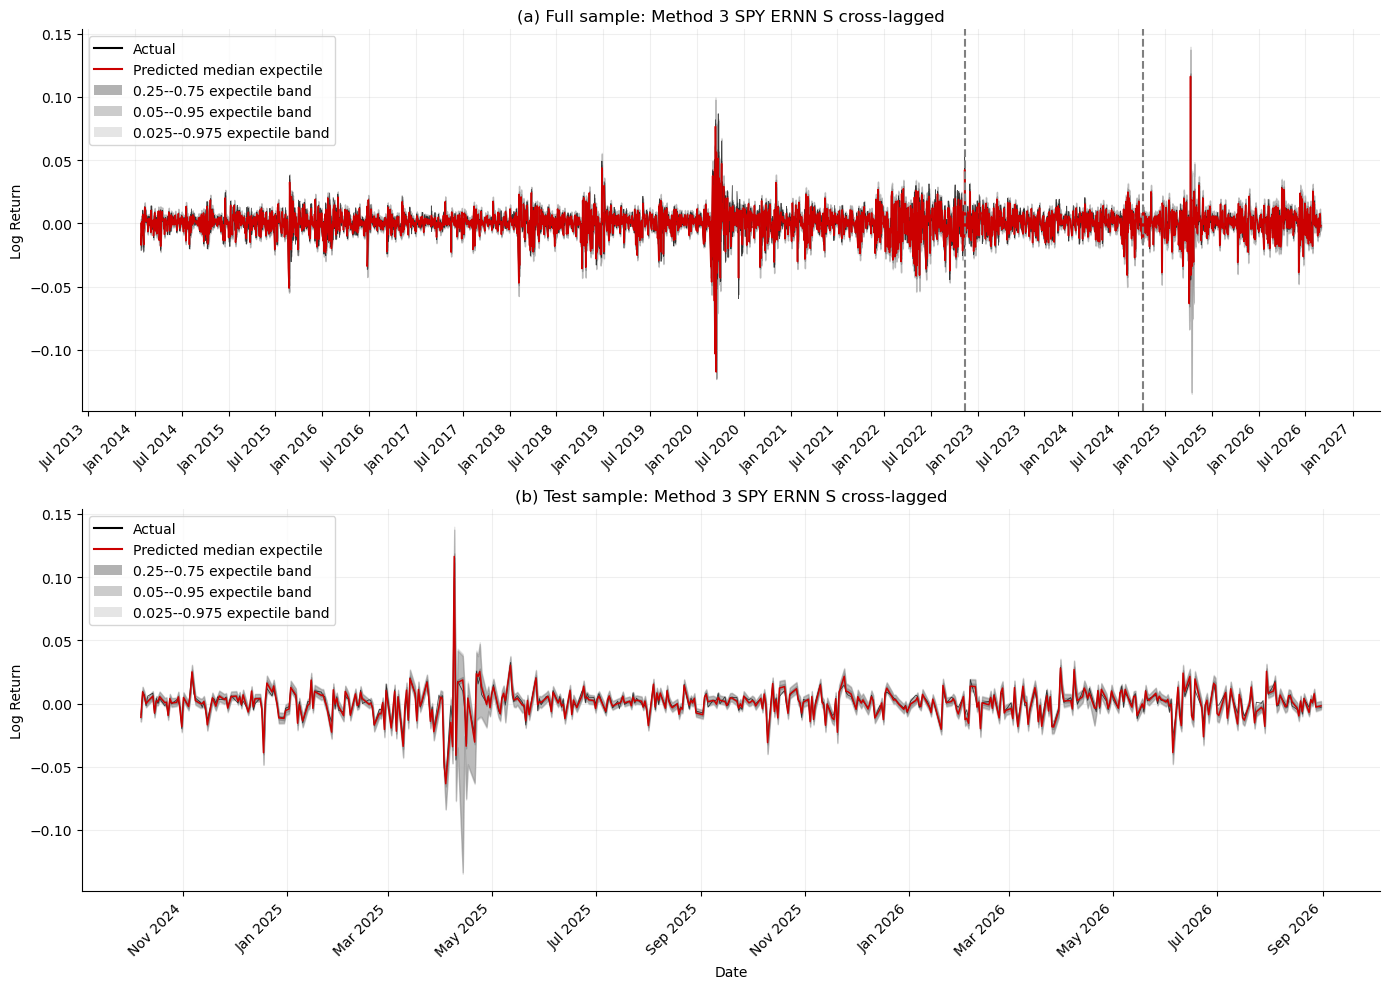


METHOD 3 SPY ERNN S CROSS-LAGGED -- TEST RESULTS
                    model  test_T  average_nll  average_ase  crossover  tail
Method 3 SPY ERNN S Cross     476    -3.778486     0.000004          0     0

Per-level results:
  tau       nll      ase    sigma
0.025 -2.869578 0.000003 0.001350
0.050 -2.793912 0.000006 0.001732
0.250 -4.253738 0.000005 0.003248
0.500 -4.260245 0.000006 0.003978
0.750 -4.237214 0.000005 0.002974
0.950 -4.046405 0.000002 0.002099
0.975 -3.988309 0.000001 0.001630

Learned-spacing diagnostics:
  tau  reference_tau direction  mean_delta  min_delta  max_delta  sd_delta  near_zero_count  near_zero_rate
0.025           0.05     lower    0.000797   0.000054   0.001340  0.000127                0             0.0
0.050           0.25     lower    0.003686   0.001145   0.150579  0.008500                0             0.0
0.250           0.50     lower    0.001045   0.000426   0.002665  0.000279                0             0.0
0.750           0.50     upper    0.001635

In [26]:
"""Plot and evaluate Method 3 SPY ERNN S cross-lagged on the test sample.

Run after the tuning/data-preparation code. Expected notebook objects:
df, train_df, val_df, test_df, feature_cols, X_train and Method3SpacingModel.
"""

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

RESULT_DIR = Path("spy_method3_spacing_ernn_s_cross_results")
MODEL_DIR = RESULT_DIR / "ernn_s_cross"
CHECKPOINT_PATH = MODEL_DIR / "method3_spacing_ernn_s_cross_best.pt"
PLOT_PATH = MODEL_DIR / "spy_method3_spacing_ernn_s_cross.png"
METRICS_PATH = MODEL_DIR / "spy_method3_spacing_ernn_s_cross_test_metrics.csv"
SUMMARY_PATH = MODEL_DIR / "spy_method3_spacing_ernn_s_cross_test_summary.csv"
DELTA_PATH = MODEL_DIR / "spy_method3_spacing_ernn_s_cross_delta_summary.csv"
PREDICTIONS_PATH = MODEL_DIR / "spy_method3_spacing_ernn_s_cross_test_predictions.csv"


required_objects = (
    "df", "train_df", "val_df", "test_df", "feature_cols", "X_train"
)
missing = [name for name in required_objects if name not in globals()]
if missing:
    raise NameError("Run the data-preparation cells first. Missing: " + ", ".join(missing))

if "Method3SpacingModel" not in globals():
    raise RuntimeError(
        "Run the Method 3 tuning/definition cell first."
    )

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT_PATH}. Run the tuning code first."
    )


# ---------------------------------------------------------------------------
# Reload all seven selected level models
# ---------------------------------------------------------------------------

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
if checkpoint.get("distribution") != "ernn":
    raise ValueError("The checkpoint is not an ERNN checkpoint.")
if checkpoint.get("form") != "s" or checkpoint.get("lag") != "cross":
    raise ValueError("The checkpoint is not the SPY ERNN S cross-lagged model.")

models = {}
for level in ORDER:
    model = Method3SpacingModel(
        input_dim=X_train.shape[1],
        config=checkpoint["configs"][level],
        distribution="ernn",
        form="s",
        lag="cross",
        direction=checkpoint["direction"][level],
    )
    model.load_state_dict(checkpoint["model_state_dicts"][level])
    model.eval()
    models[level] = model


# ---------------------------------------------------------------------------
# Generate full-sample forecasts sequentially from the median outwards
# ---------------------------------------------------------------------------

X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
y_all = torch.tensor(df["log_return"].values, dtype=torch.float32)
predictions, deltas, sigmas = {}, {}, {}

for level in ORDER:
    reference_level = REFERENCE[level]
    reference = None if reference_level is None else predictions[reference_level]
    with torch.no_grad():
        prediction, _, _, delta, sigma = models[level](y_all, X_all, reference)
    predictions[level] = prediction.detach()
    deltas[level] = None if delta is None else delta.detach()
    sigmas[level] = sigma.detach()

test_start = len(train_df) + len(val_df)
y_test = y_all[test_start:]
test_dates = test_df.index

if len(y_test) != len(test_dates):
    raise ValueError("The calculated test slice does not match test_df.")


# ---------------------------------------------------------------------------
# Plot full sample and test sample
# ---------------------------------------------------------------------------

prediction_np = {level: predictions[level].cpu().numpy() for level in LEVELS}
actual_np = df["log_return"].to_numpy()


def draw_panel(axis, dates, actual, start=None):
    def values(level):
        series = prediction_np[level]
        return series if start is None else series[start:]

    axis.plot(dates, actual, color="#000000", linewidth=0.6, alpha=0.70)
    axis.plot(dates, values(0.500), color="#CC0000", linewidth=1.1)
    axis.fill_between(dates, values(0.025), values(0.975), color="#808080", alpha=0.20)
    axis.fill_between(dates, values(0.050), values(0.950), color="#808080", alpha=0.40)
    axis.fill_between(dates, values(0.250), values(0.750), color="#808080", alpha=0.60)
    axis.set_ylabel("Log Return")
    axis.grid(True, alpha=0.20)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


figure, axes = plt.subplots(2, 1, figsize=(14, 10))
draw_panel(axes[0], df.index, actual_np)
axes[0].axvline(train_df.index[-1], color="gray", linestyle="--")
axes[0].axvline(val_df.index[-1], color="gray", linestyle="--")
axes[0].set_title("(a) Full sample: Method 3 SPY ERNN S cross-lagged")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

draw_panel(axes[1], test_dates, test_df["log_return"].to_numpy(), start=test_start)
axes[1].set_title("(b) Test sample: Method 3 SPY ERNN S cross-lagged")
axes[1].set_xlabel("Date")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

legend = [
    Line2D([0], [0], color="#000000", label="Actual"),
    Line2D([0], [0], color="#CC0000", label="Predicted median expectile"),
    Patch(facecolor="#808080", alpha=0.60, label="0.25--0.75 expectile band"),
    Patch(facecolor="#808080", alpha=0.40, label="0.05--0.95 expectile band"),
    Patch(facecolor="#808080", alpha=0.20, label="0.025--0.975 expectile band"),
]
for axis in axes:
    axis.legend(handles=legend, loc="upper left")
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ---------------------------------------------------------------------------
# Test AGD NLL and asymmetric squared error
# ---------------------------------------------------------------------------


def agd_nll(y, expectile, sigma, tau):
    residual = y - expectile
    tau_tensor = torch.tensor(tau, dtype=y.dtype, device=y.device)
    weight = torch.abs(tau_tensor - (residual < 0).to(y.dtype))
    constant = (
        torch.log(
            torch.sqrt(torch.pi / tau_tensor)
            + torch.sqrt(torch.pi / (1.0 - tau_tensor))
        )
        - np.log(2.0)
    )
    return (
        torch.log(sigma)
        + constant
        + weight * residual.square() / sigma.square()
    ).mean()


def asymmetric_squared_error(y, expectile, tau):
    residual = y - expectile
    weight = torch.where(
        residual >= 0,
        torch.full_like(residual, tau),
        torch.full_like(residual, 1.0 - tau),
    )
    return (weight * residual.square()).mean()


metric_rows = []
for level in LEVELS:
    prediction_test = predictions[level][test_start:]
    metric_rows.append({
        "tau": level,
        "nll": agd_nll(y_test, prediction_test, sigmas[level], level).item(),
        "ase": asymmetric_squared_error(y_test, prediction_test, level).item(),
        "sigma": sigmas[level].item(),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(METRICS_PATH, index=False)


# ---------------------------------------------------------------------------
# Crossover and learned-spacing diagnostics
# ---------------------------------------------------------------------------

test_matrix = torch.stack(
    [predictions[level][test_start:] for level in LEVELS], dim=1
)
violations = test_matrix[:, :-1] > test_matrix[:, 1:]
pair_counts = violations.sum(dim=0)
total_crossover = int(violations.sum().item())
tail_crossover = int((pair_counts[0] + pair_counts[-1]).item())

delta_rows = []
for level in LEVELS:
    if deltas[level] is None:
        continue
    delta_test = deltas[level][test_start:]
    delta_rows.append({
        "tau": level,
        "reference_tau": REFERENCE[level],
        "direction": DIRECTION[level],
        "mean_delta": delta_test.mean().item(),
        "min_delta": delta_test.min().item(),
        "max_delta": delta_test.max().item(),
        "sd_delta": delta_test.std(unbiased=False).item(),
        "near_zero_count": int((delta_test < 1e-6).sum().item()),
        "near_zero_rate": (delta_test < 1e-6).float().mean().item(),
    })

delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(DELTA_PATH, index=False)

summary_df = pd.DataFrame([{
    "model": "Method 3 SPY ERNN S Cross",
    "test_T": len(y_test),
    "average_nll": metrics_df["nll"].mean(),
    "average_ase": metrics_df["ase"].mean(),
    "crossover": total_crossover,
    "tail": tail_crossover,
}])
summary_df.to_csv(SUMMARY_PATH, index=False)


# ---------------------------------------------------------------------------
# Detailed test predictions and adjacent gaps
# ---------------------------------------------------------------------------

prediction_table = pd.DataFrame({
    "date": test_dates,
    "actual": y_test.cpu().numpy(),
})
for level in LEVELS:
    prediction_table[f"e_{level:.3f}"] = predictions[level][test_start:].cpu().numpy()
for left, right in zip(LEVELS[:-1], LEVELS[1:]):
    prediction_table[f"gap_{left:.3f}_{right:.3f}"] = (
        predictions[right][test_start:] - predictions[left][test_start:]
    ).cpu().numpy()
prediction_table["min_adjacent_gap"] = prediction_table[
    [column for column in prediction_table if column.startswith("gap_")]
].min(axis=1)
prediction_table.to_csv(PREDICTIONS_PATH, index=False)


print("\nMETHOD 3 SPY ERNN S CROSS-LAGGED -- TEST RESULTS")
print(summary_df.to_string(index=False))
print("\nPer-level results:")
print(metrics_df.to_string(index=False))
print("\nLearned-spacing diagnostics:")
print(delta_df.to_string(index=False))
print("\nMagnitude diagnostics:")
print(f"Maximum absolute test forecast: "
      f"{test_matrix.abs().max().item():.8f}")
print(f"Maximum learned test spacing: "
      f"{delta_df['max_delta'].max():.8f}")
print(f"\nPlot saved to: {PLOT_PATH}")
print(f"Detailed predictions saved to: {PREDICTIONS_PATH}")

## Crossover - Penalty

Joint seven-level estimation with an adjacent final-output crossing penalty.


In [29]:
# ============================================================
# SPY CROSSOVER — FINAL-OUTPUT PENALTY ERNN S CROSS-LAGGED
# HYBRID ERNN A — SELF-LAGGED
# ============================================================

import copy
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from optuna.samplers import TPESampler


# ------------------------------------------------------------
# 1. Settings
# ------------------------------------------------------------

PENALTY_TAU_LEVELS = [
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975
]

PENALTY_LAMBDA_GRID = [
    0.01, 0.1, 1.0, 10.0, 100.0
]

PENALTY_N_TRIALS = 200
PENALTY_MAX_EPOCHS = 800
PENALTY_SEED = 2026

PENALTY_OUTPUT_DIR = Path(
    "spy_penalty_crossover_results/spy_ernn_s_cross"
)
PENALTY_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Recover the test tensors used by the original notebooks.
# The sorting/PAVA sections call them X_test_q and y_test_q,
# whereas this joint penalty code uses X_test and y_test.
if "X_test" not in globals():
    if "X_test_q" in globals():
        X_test = X_test_q
    elif "test_df" in globals() and "feature_cols" in globals():
        X_test = torch.tensor(
            test_df[feature_cols].values,
            dtype=torch.float32
        )

if "y_test" not in globals():
    if "y_test_q" in globals():
        y_test = y_test_q
    elif "test_df" in globals():
        y_test = torch.tensor(
            test_df["log_return"].values,
            dtype=torch.float32
        )

required_objects = [
    "X_train", "y_train",
    "X_val", "y_val",
    "X_test", "y_test"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing required data objects:\n"
        + ", ".join(missing_objects)
        + "\nRun the data-preparation and sorting setup cells first."
    )


# ------------------------------------------------------------
# 2. Joint unrestricted Hybrid ERNN
# ------------------------------------------------------------

PENALTY_FORM = "S"
PENALTY_LAG = "cross"

class PenaltyHybridERNN_Generic(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()
        self.n_levels = len(PENALTY_TAU_LEVELS)
        self.eps = 1e-6
        self.beta1_raw = nn.Parameter(torch.full((self.n_levels,), 1.386))
        self.beta2_raw = nn.Parameter(torch.full((self.n_levels,), 0.3))
        self.beta3_raw = nn.Parameter(torch.full((self.n_levels,), 0.3))
        self.psi_raw = nn.Parameter(torch.zeros(self.n_levels))
        self.sigma_raw = nn.Parameter(torch.full((self.n_levels,), 0.5))
        layers = []
        previous_dim = input_dim
        for i in range(config["n_hidden_layers"]):
            hidden_dim = config[f"hidden_dim_{i}"]
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append({"relu": nn.ReLU(), "elu": nn.ELU(), "gelu": nn.GELU(), "tanh": nn.Tanh()}[config["activation"]])
            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))
            previous_dim = hidden_dim
        self.feature_extractor = nn.Sequential(*layers)
        self.output_head = nn.Linear(previous_dim, self.n_levels)
        for module in self.modules():
            if isinstance(module, nn.Linear):
                if config["weight_init"] == "glorot":
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, y, X, initial_caviar=None, initial_y=None):
        if (initial_caviar is None) != (initial_y is None):
            raise ValueError("initial_caviar and initial_y must be supplied together.")
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = F.softplus(self.beta2_raw)
        beta3 = F.softplus(self.beta3_raw)
        psi = torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + self.eps
        fnn_outputs = self.output_head(self.feature_extractor(X))
        zero_state = y.new_zeros(self.n_levels)
        previous_state = initial_caviar if initial_caviar is not None else zero_state
        caviar_sequence, hybrid_sequence = [], []
        for t in range(len(y)):
            if t == 0 and initial_caviar is None:
                caviar_sequence.append(zero_state)
                hybrid_sequence.append(zero_state)
                continue
            previous_y = initial_y if t == 0 else y[t - 1]
            abs_y = torch.abs(previous_y)
            if PENALTY_FORM == "S":
                caviar_t = beta1 * previous_state + beta2 * abs_y
            elif PENALTY_FORM == "A":
                caviar_t = (beta1 * previous_state
                            + beta2 * torch.clamp(previous_y, min=0)
                            + beta3 * torch.clamp(-previous_y, min=0))
            elif PENALTY_FORM == "SI":
                caviar_t = (beta1 * previous_state + beta2 * abs_y
                            + beta3 * previous_state * abs_y)
            else:
                raise ValueError(f"Unknown form: {PENALTY_FORM}")
            hybrid_t = psi * caviar_t + (1.0 - psi) * fnn_outputs[t]
            caviar_sequence.append(caviar_t)
            hybrid_sequence.append(hybrid_t)
            previous_state = caviar_t if PENALTY_LAG == "self" else hybrid_t
        return torch.stack(hybrid_sequence), sigma, torch.stack(caviar_sequence), fnn_outputs


# ------------------------------------------------------------
# 4. AGD forecasting loss
# ------------------------------------------------------------

def penalty_ernn_agd_loss(y, e_forecasts, sigma):
    """Average AGD NLL over observations and seven expectile levels."""
    tau = e_forecasts.new_tensor(PENALTY_TAU_LEVELS)
    residual = y.unsqueeze(1) - e_forecasts
    weight = torch.abs(tau.unsqueeze(0) - (residual < 0).to(e_forecasts.dtype))
    omega = weight * residual.pow(2)
    constant = (torch.log(torch.sqrt(torch.pi / tau) + torch.sqrt(torch.pi / (1.0 - tau))) - np.log(2.0))
    nll = torch.log(sigma).unsqueeze(0) + constant.unsqueeze(0) + omega / sigma.pow(2).unsqueeze(0)
    return nll.mean()


def penalty_ernn_nll_by_level(y, e_forecasts, sigma):
    tau = e_forecasts.new_tensor(PENALTY_TAU_LEVELS)
    residual = y.unsqueeze(1) - e_forecasts
    weight = torch.abs(tau.unsqueeze(0) - (residual < 0).to(e_forecasts.dtype))
    omega = weight * residual.pow(2)
    constant = (torch.log(torch.sqrt(torch.pi / tau) + torch.sqrt(torch.pi / (1.0 - tau))) - np.log(2.0))
    nll = torch.log(sigma).unsqueeze(0) + constant.unsqueeze(0) + omega / sigma.pow(2).unsqueeze(0)
    return nll.mean(dim=0)


# ------------------------------------------------------------
# 5. Fakoor-style adjacent crossing penalty
# ------------------------------------------------------------

def adjacent_crossing_penalty(q_forecasts):
    """
    q_forecasts has shape (T, 7).

    A positive value occurs whenever the lower-level
    forecast exceeds the adjacent higher-level forecast.
    """

    crossing_amounts = F.relu(
        q_forecasts[:, :-1]
        - q_forecasts[:, 1:]
    )

    return crossing_amounts.mean()


def penalty_crossover_diagnostics(q_forecasts):

    violations = (
        q_forecasts[:, :-1]
        > q_forecasts[:, 1:]
    )

    pair_counts = violations.sum(dim=0)
    number_of_observations = q_forecasts.shape[0]

    total_count = int(
        pair_counts.sum().item()
    )

    tail_count = int(
        pair_counts[0].item()
        + pair_counts[-1].item()
    )

    return {
        "pair_counts": [
            int(value)
            for value in pair_counts.tolist()
        ],
        "total_count": total_count,
        "total_rate": (
            total_count
            / (number_of_observations * 6)
        ),
        "tail_count": tail_count,
        "tail_rate": (
            tail_count
            / (number_of_observations * 2)
        )
    }


def penalty_ase_diagnostics(y, e_forecasts):
    """Asymmetric squared error by level and averaged over levels."""
    tau = e_forecasts.new_tensor(PENALTY_TAU_LEVELS)
    residual = y.unsqueeze(1) - e_forecasts
    weight = torch.abs(tau.unsqueeze(0) - (residual < 0).to(e_forecasts.dtype))
    ase_by_level = (weight * residual.pow(2)).mean(dim=0)
    return None, ase_by_level, ase_by_level.mean()


# ------------------------------------------------------------
# 6. Fit one Optuna configuration
# ------------------------------------------------------------

def fit_penalty_spy_ernn_s_cross(
    config,
    max_epochs=PENALTY_MAX_EPOCHS,
    seed=PENALTY_SEED
):

    torch.manual_seed(seed)
    np.random.seed(seed)

    model = PenaltyHybridERNN_Generic(
        input_dim=X_train.shape[1],
        config=config
    )

    optimizer_class = (
        torch.optim.Adam
        if config["optimizer"] == "adam"
        else torch.optim.AdamW
    )

    optimizer = optimizer_class(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            patience=10,
            factor=0.5,
            min_lr=1e-6
        )
    )

    best_validation_objective = float("inf")
    best_model_state = None
    patience_counter = 0

    for epoch in range(max_epochs):

        model.train()
        optimizer.zero_grad()

        (
            q_train,
            sigma_train,
            _,
            _
        ) = model(
            y_train,
            X_train
        )

        forecast_loss = penalty_ernn_agd_loss(
            y_train[1:],
            q_train[1:],
            sigma_train
        )

        crossing_loss = adjacent_crossing_penalty(
            q_train[1:]
        )

        total_training_loss = (
            forecast_loss
            + config["lambda_cross"]
            * crossing_loss
        )

        if not torch.isfinite(total_training_loss):
            return None

        total_training_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config["gradient_clip"]
        )

        optimizer.step()

        model.eval()

        with torch.no_grad():

            (
                _,
                _,
                final_train_caviar,
                _
            ) = model(
                y_train,
                X_train
            )

            (
                q_validation,
                sigma_validation,
                _,
                _
            ) = model(
                y_val,
                X_val,
                initial_caviar=final_train_caviar[-1],
                initial_y=y_train[-1]
            )

            validation_nll = penalty_ernn_agd_loss(
                y_val,
                q_validation,
                sigma_validation
            )

            validation_crossing_loss = (
                adjacent_crossing_penalty(
                    q_validation
                )
            )

            validation_objective = (
                validation_nll
                + config["lambda_cross"]
                * validation_crossing_loss
            )

        if not torch.isfinite(validation_objective):
            return None

        scheduler.step(
            validation_objective.item()
        )

        if (
            validation_objective.item()
            < best_validation_objective
        ):
            best_validation_objective = (
                validation_objective.item()
            )
            best_model_state = copy.deepcopy(
                model.state_dict()
            )
            patience_counter = 0

        else:
            patience_counter += 1

            if (
                patience_counter
                >= config["patience"]
            ):
                break

    if best_model_state is None:
        return None

    model.load_state_dict(best_model_state)

    return model


# ------------------------------------------------------------
# 7. Validation evaluation
# ------------------------------------------------------------

def evaluate_penalty_validation(model):

    model.eval()

    with torch.no_grad():

        (
            _,
            _,
            final_train_caviar,
            _
        ) = model(
            y_train,
            X_train
        )

        (
            q_validation,
            sigma,
            _,
            _
        ) = model(
            y_val,
            X_val,
            initial_caviar=final_train_caviar[-1],
            initial_y=y_train[-1]
        )

        average_nll = penalty_ernn_agd_loss(
            y_val,
            q_validation,
            sigma
        ).item()

        crossing_loss = (
            adjacent_crossing_penalty(
                q_validation
            ).item()
        )

        (
            hit_rates,
            ase_by_level,
            average_ase
        ) = penalty_ase_diagnostics(
            y_val,
            q_validation
        )

        crossover = (
            penalty_crossover_diagnostics(
                q_validation
            )
        )

    return {
        "average_nll": average_nll,
        "average_ase": average_ase.item(),
        "ase_by_level": ase_by_level.tolist(),
        "crossing_loss": crossing_loss,
        "crossover": crossover,
        "sigma": sigma.tolist()
    }


# ------------------------------------------------------------
# 8. Optuna objective
# ------------------------------------------------------------

def objective_penalty_spy_ernn_s_cross(trial):

    config = {
        "n_hidden_layers": trial.suggest_int(
            "n_hidden_layers", 1, 3
        ),
        "activation": trial.suggest_categorical(
            "activation",
            ["relu", "elu", "gelu", "tanh"]
        ),
        "dropout": trial.suggest_float(
            "dropout", 0.0, 0.5
        ),
        "layernorm": trial.suggest_categorical(
            "layernorm", [True, False]
        ),
        "weight_init": trial.suggest_categorical(
            "weight_init", ["glorot", "he"]
        ),
        "lr": trial.suggest_float(
            "lr", 1e-4, 5e-2, log=True
        ),
        "optimizer": trial.suggest_categorical(
            "optimizer", ["adam", "adamw"]
        ),
        "weight_decay": trial.suggest_float(
            "weight_decay", 0.0, 1e-4
        ),
        "gradient_clip": trial.suggest_categorical(
            "gradient_clip", [0.1, 1.0, 5.0]
        ),
        "patience": trial.suggest_categorical(
            "patience", [10, 20, 30]
        ),
        "lambda_cross": trial.suggest_categorical(
            "lambda_cross",
            PENALTY_LAMBDA_GRID
        )
    }

    for i in range(
        config["n_hidden_layers"]
    ):
        config[f"hidden_dim_{i}"] = (
            trial.suggest_int(
                f"hidden_dim_{i}",
                32,
                256
            )
        )

    model = fit_penalty_spy_ernn_s_cross(
        config=config
    )

    if model is None:
        return float("inf")

    metrics = evaluate_penalty_validation(
        model
    )

    trial.set_user_attr(
        "average_nll",
        metrics["average_nll"]
    )
    trial.set_user_attr(
        "average_ase",
        metrics["average_ase"]
    )
    trial.set_user_attr(
        "crossing_loss",
        metrics["crossing_loss"]
    )
    trial.set_user_attr(
        "crossover_count",
        metrics["crossover"]["total_count"]
    )
    trial.set_user_attr(
        "crossover_rate",
        metrics["crossover"]["total_rate"]
    )
    trial.set_user_attr(
        "tail_count",
        metrics["crossover"]["tail_count"]
    )
    trial.set_user_attr(
        "tail_rate",
        metrics["crossover"]["tail_rate"]
    )
    trial.set_user_attr(
        "pair_counts",
        metrics["crossover"]["pair_counts"]
    )
    trial.set_user_attr(
        "ase_by_level",
        metrics["ase_by_level"]
    )
    trial.set_user_attr(
        "sigma",
        metrics["sigma"]
    )

    print(
        f"Trial {trial.number}: "
        f"NLL={metrics['average_nll']:.6f} | "
        f"ASE={metrics['average_ase']:.6f} | "
        f"crossovers="
        f"{metrics['crossover']['total_count']} | "
        f"lambda={config['lambda_cross']}"
    )

    # Strongly prioritise removing validation crossing.
    # NLL distinguishes trials with the same crossing rate.
    selection_objective = (
        1000.0
        * metrics["crossover"]["total_rate"]
        + metrics["average_nll"]
    )

    return selection_objective


# ------------------------------------------------------------
# 9. Final trial selection
# ------------------------------------------------------------

def select_penalty_trial(study):

    valid_trials = [
        trial
        for trial in study.trials
        if (
            trial.state
            == optuna.trial.TrialState.COMPLETE
            and trial.value is not None
            and np.isfinite(trial.value)
            and "average_nll"
            in trial.user_attrs
        )
    ]

    if not valid_trials:
        raise RuntimeError(
            "No valid Optuna trials were completed."
        )

    minimum_crossovers = min(
        trial.user_attrs["crossover_count"]
        for trial in valid_trials
    )

    eligible_trials = [
        trial
        for trial in valid_trials
        if (
            trial.user_attrs["crossover_count"]
            == minimum_crossovers
        )
    ]

    nll_order = sorted(
        eligible_trials,
        key=lambda trial: (
            trial.user_attrs["average_nll"],
            trial.number
        )
    )

    ase_order = sorted(
        eligible_trials,
        key=lambda trial: (
            trial.user_attrs["average_ase"],
            trial.number
        )
    )

    nll_rank = {
        trial.number: rank
        for rank, trial in enumerate(
            nll_order,
            start=1
        )
    }

    ase_rank = {
        trial.number: rank
        for rank, trial in enumerate(
            ase_order,
            start=1
        )
    }

    selected_trial = min(
        eligible_trials,
        key=lambda trial: (
            nll_rank[trial.number]
            + ase_rank[trial.number],
            trial.user_attrs["average_nll"],
            trial.user_attrs["average_ase"],
            trial.number
        )
    )

    return (
        selected_trial,
        valid_trials,
        minimum_crossovers
    )


# ------------------------------------------------------------
# 10. Run tuning
# ------------------------------------------------------------

print("\n" + "=" * 76)
print("TUNING — PENALTY HYBRID ERNN S SELF-LAGGED")
print("=" * 76)

penalty_sampler_spy_ernn_s_cross = TPESampler(
    seed=PENALTY_SEED
)

penalty_study_spy_ernn_s_cross = (
    optuna.create_study(
        direction="minimize",
        sampler=penalty_sampler_spy_ernn_s_cross
    )
)

penalty_study_spy_ernn_s_cross.optimize(
    objective_penalty_spy_ernn_s_cross,
    n_trials=PENALTY_N_TRIALS,
    show_progress_bar=True
)

(
    penalty_best_trial_spy_ernn_s_cross,
    penalty_valid_trials_spy_ernn_s_cross,
    penalty_minimum_validation_crossovers
) = select_penalty_trial(
    penalty_study_spy_ernn_s_cross
)


# ------------------------------------------------------------
# 11. Save trial ranking
# ------------------------------------------------------------

penalty_ranking_records = []

for trial in penalty_valid_trials_spy_ernn_s_cross:

    record = {
        "trial": trial.number,
        "selection_objective": trial.value,
        "validation_nll":
            trial.user_attrs["average_nll"],
        "validation_ase":
            trial.user_attrs["average_ase"],
        "validation_crossing_loss":
            trial.user_attrs["crossing_loss"],
        "validation_crossover":
            trial.user_attrs["crossover_count"],
        "validation_crossover_rate":
            trial.user_attrs["crossover_rate"],
        "validation_tail":
            trial.user_attrs["tail_count"],
        "validation_tail_rate":
            trial.user_attrs["tail_rate"]
    }

    record.update(trial.params)
    penalty_ranking_records.append(record)

penalty_ranking_df = pd.DataFrame(
    penalty_ranking_records
).sort_values(
    [
        "validation_crossover",
        "validation_nll",
        "validation_ase",
        "trial"
    ]
)

penalty_ranking_path = (
    PENALTY_OUTPUT_DIR
    / "penalty_spy_ernn_s_cross_ranking.csv"
)

penalty_ranking_df.to_csv(
    penalty_ranking_path,
    index=False
)


# ------------------------------------------------------------
# 12. Refit selected model
# ------------------------------------------------------------

penalty_best_config_spy_ernn_s_cross = (
    penalty_best_trial_spy_ernn_s_cross.params.copy()
)

penalty_best_model_spy_ernn_s_cross = (
    fit_penalty_spy_ernn_s_cross(
        config=penalty_best_config_spy_ernn_s_cross
    )
)

if penalty_best_model_spy_ernn_s_cross is None:
    raise RuntimeError(
        "The selected penalty model failed to refit."
    )


# ------------------------------------------------------------
# 13. Final validation and test forecasts
# ------------------------------------------------------------

penalty_best_model_spy_ernn_s_cross.eval()

with torch.no_grad():

    (
        _,
        _,
        final_train_caviar,
        _
    ) = penalty_best_model_spy_ernn_s_cross(
        y_train,
        X_train
    )

    (
        q_penalty_validation,
        sigma_penalty,
        final_validation_caviar,
        _
    ) = penalty_best_model_spy_ernn_s_cross(
        y_val,
        X_val,
        initial_caviar=final_train_caviar[-1],
        initial_y=y_train[-1]
    )

    (
        q_penalty_test,
        sigma_penalty,
        _,
        _
    ) = penalty_best_model_spy_ernn_s_cross(
        y_test,
        X_test,
        initial_caviar=final_validation_caviar[-1],
        initial_y=y_val[-1]
    )

    penalty_test_nll_by_level = (
        penalty_ernn_nll_by_level(
            y_test,
            q_penalty_test,
            sigma_penalty
        )
    )

    penalty_average_test_nll = (
        penalty_test_nll_by_level.mean().item()
    )

    (
        penalty_test_hit_rates,
        penalty_test_ase_by_level,
        penalty_average_test_ase
    ) = penalty_ase_diagnostics(
        y_test,
        q_penalty_test
    )

    penalty_test_crossover = (
        penalty_crossover_diagnostics(
            q_penalty_test
        )
    )


# ------------------------------------------------------------
# 14. Save selected model and predictions
# ------------------------------------------------------------

penalty_checkpoint_path = (
    PENALTY_OUTPUT_DIR
    / "penalty_spy_ernn_s_cross_best.pt"
)

torch.save(
    {
        "model_state_dict":
            penalty_best_model_spy_ernn_s_cross.state_dict(),
        "config":
            penalty_best_config_spy_ernn_s_cross,
        "alpha_levels":
            PENALTY_TAU_LEVELS,
        "method":
            "Final-output adjacent crossing penalty",
        "reference":
            "Adapted from Fakoor et al. (2023)"
    },
    penalty_checkpoint_path
)

prediction_columns = {
    "actual": y_test.detach().cpu().numpy()
}

for level_index, tau in enumerate(
    PENALTY_TAU_LEVELS
):
    prediction_columns[
        f"q_{tau:.3f}"
    ] = (
        q_penalty_test[:, level_index]
        .detach()
        .cpu()
        .numpy()
    )

penalty_predictions_df = pd.DataFrame(
    prediction_columns
)

penalty_predictions_path = (
    PENALTY_OUTPUT_DIR
    / "penalty_spy_ernn_s_cross_test_predictions.csv"
)

penalty_predictions_df.to_csv(
    penalty_predictions_path,
    index=False
)


# ------------------------------------------------------------
# 15. Save per-level and summary metrics
# ------------------------------------------------------------

penalty_level_metrics = pd.DataFrame({
    "tau": PENALTY_TAU_LEVELS,
    "test_nll": (
        penalty_test_nll_by_level
        .detach()
        .cpu()
        .numpy()
    ),
    "ase": (
        penalty_test_ase_by_level
        .detach()
        .cpu()
        .numpy()
    ),
    "sigma": (
        sigma_penalty
        .detach()
        .cpu()
        .numpy()
    )
})

penalty_level_metrics_path = (
    PENALTY_OUTPUT_DIR
    / "penalty_spy_ernn_s_cross_test_metrics.csv"
)

penalty_level_metrics.to_csv(
    penalty_level_metrics_path,
    index=False
)

penalty_summary_df = pd.DataFrame([{
    "model": "Penalty Hybrid ERNN S self",
    "test_T": len(y_test),
    "selected_trial":
        penalty_best_trial_spy_ernn_s_cross.number,
    "lambda_cross":
        penalty_best_config_spy_ernn_s_cross[
            "lambda_cross"
        ],
    "average_nll":
        penalty_average_test_nll,
    "average_ase":
        penalty_average_test_ase.item(),
    "crossover":
        penalty_test_crossover["total_count"],
    "crossover_rate":
        penalty_test_crossover["total_rate"],
    "tail":
        penalty_test_crossover["tail_count"],
    "tail_rate":
        penalty_test_crossover["tail_rate"]
}])

penalty_summary_path = (
    PENALTY_OUTPUT_DIR
    / "penalty_spy_ernn_s_cross_summary.csv"
)

penalty_summary_df.to_csv(
    penalty_summary_path,
    index=False
)


[I 2026-09-27 20:10:59,472] A new study created in memory with name: no-name-200a3a65-de5f-4f95-ab1a-1096afd61aee



TUNING — PENALTY HYBRID ERNN S SELF-LAGGED


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: NLL=1.432415 | ASE=0.051659 | crossovers=12 | lambda=10.0
[I 2026-09-27 20:11:12,009] Trial 0 finished with value: 5.642941443543685 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'lambda_cross': 10.0, 'hidden_dim_0': 249}. Best is trial 0 with value: 5.642941443543685.
Trial 1: NLL=-1.172804 | ASE=0.000006 | crossovers=4 | lambda=1.0
[I 2026-09-27 20:13:47,917] Trial 1 finished with value: 0.2307048931456448 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.3414601860914257, 'layernorm': True, 'weight_init': 'he', 'lr': 0.003552030928655712, 'optimizer': 'adam', 'weight_decay': 4.5088356047414194e-05, 'gradient_clip': 0.1, 'patience': 10, 'lambda_cross': 1.0, 'hidden_dim_0': 251}. Best is trial 1 with value: 0.2307048931456448.
Trial 2: NLL=-1

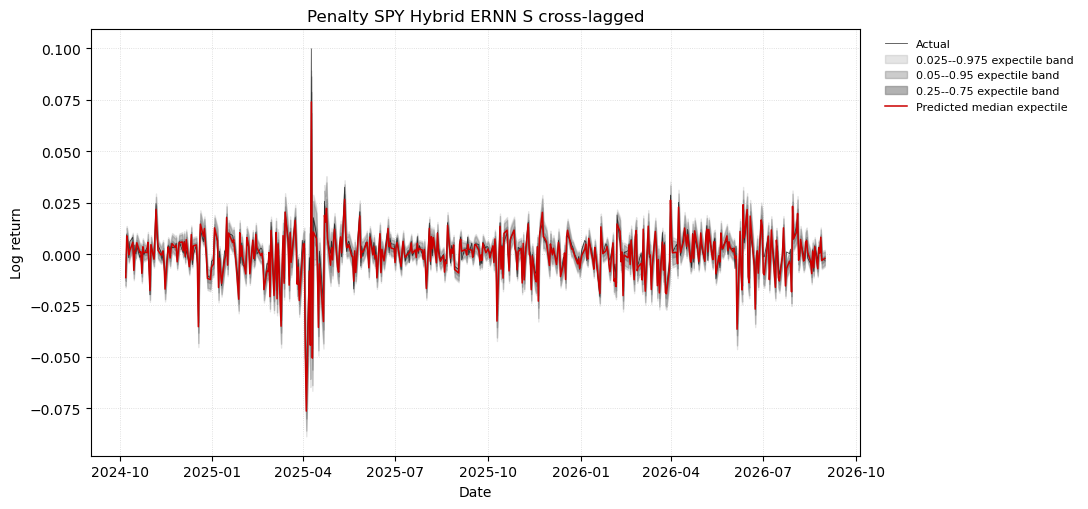


TEST RESULTS — PENALTY SPY ERNN S CROSS-LAGGED
       tau    test_nll        ase      sigma
0.02500000 -3.92994475 0.00000166 0.00169674
0.05000000 -4.00127602 0.00000257 0.00213229
0.25000000 -4.15211248 0.00000582 0.00336053
0.50000000 -4.20898247 0.00000645 0.00371959
0.75000000 -4.21212244 0.00000511 0.00345050
0.95000000 -4.05107641 0.00000233 0.00228223
0.97500000 -3.96459031 0.00000156 0.00184877

SUMMARY
Selected trial:       #81
Selected lambda:      0.01
Average test NLL:     -4.074301
Average test ASE:     0.000004
Test crossover:       0 (0.00%)
Test tail violations: 0 (0.00%)

Saved outputs:
  spy_penalty_crossover_results/spy_ernn_s_cross/penalty_spy_ernn_s_cross_ranking.csv
  spy_penalty_crossover_results/spy_ernn_s_cross/penalty_spy_ernn_s_cross_best.pt
  spy_penalty_crossover_results/spy_ernn_s_cross/penalty_spy_ernn_s_cross_test_predictions.csv
  spy_penalty_crossover_results/spy_ernn_s_cross/penalty_spy_ernn_s_cross_test_metrics.csv
  spy_penalty_crossover_results/s

In [31]:
# ------------------------------------------------------------
# 16. Plot final test forecasts
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5.2))

if "test_df" in globals() and len(test_df) == len(y_test):
    plot_axis = test_df.index
    x_label = "Date"
else:
    plot_axis = np.arange(len(y_test))
    x_label = "Test-period observation"

actual_values = y_test.detach().cpu().numpy()
forecast_values = q_penalty_test.detach().cpu().numpy()

def penalty_level_values(level):
    return forecast_values[:, PENALTY_TAU_LEVELS.index(level)]

ax.plot(
    plot_axis,
    actual_values,
    color="#000000",
    linewidth=0.6,
    alpha=0.70,
    label="Actual",
)
ax.fill_between(
    plot_axis,
    penalty_level_values(0.025),
    penalty_level_values(0.975),
    color="#808080",
    alpha=0.20,
    label="0.025--0.975 expectile band",
)
ax.fill_between(
    plot_axis,
    penalty_level_values(0.050),
    penalty_level_values(0.950),
    color="#808080",
    alpha=0.40,
    label="0.05--0.95 expectile band",
)
ax.fill_between(
    plot_axis,
    penalty_level_values(0.250),
    penalty_level_values(0.750),
    color="#808080",
    alpha=0.60,
    label="0.25--0.75 expectile band",
)
ax.plot(
    plot_axis,
    penalty_level_values(0.500),
    color="#CC0000",
    linewidth=1.1,
    label="Predicted median expectile",
)

ax.set_xlabel(x_label)
ax.set_ylabel("Log return")
ax.set_title("Penalty SPY Hybrid ERNN S cross-lagged")
ax.grid(linestyle=":", linewidth=0.6, alpha=0.5)
ax.legend(
    frameon=False,
    fontsize=8,
    ncol=1,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

fig.tight_layout()

penalty_plot_path = (
    PENALTY_OUTPUT_DIR
    / "penalty_spy_ernn_s_cross_predictions.png"
)

fig.savefig(
    penalty_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 17. Print final results
# ------------------------------------------------------------

print("\n" + "=" * 76)
print("TEST RESULTS — PENALTY SPY ERNN S CROSS-LAGGED")
print("=" * 76)

print(
    penalty_level_metrics.to_string(
        index=False,
        float_format=lambda value: f"{value:.8f}"
    )
)

print("\n" + "=" * 76)
print("SUMMARY")
print("=" * 76)

print(
    f"Selected trial:       "
    f"#{penalty_best_trial_spy_ernn_s_cross.number}"
)

print(
    f"Selected lambda:      "
    f"{penalty_best_config_spy_ernn_s_cross['lambda_cross']}"
)

print(
    f"Average test NLL:     "
    f"{penalty_average_test_nll:.6f}"
)

print(
    f"Average test ASE:     "
    f"{penalty_average_test_ase.item():.6f}"
)

print(
    f"Test crossover:       "
    f"{penalty_test_crossover['total_count']} "
    f"({penalty_test_crossover['total_rate']:.2%})"
)

print(
    f"Test tail violations: "
    f"{penalty_test_crossover['tail_count']} "
    f"({penalty_test_crossover['tail_rate']:.2%})"
)

print("\nSaved outputs:")

for saved_path in [
    penalty_ranking_path,
    penalty_checkpoint_path,
    penalty_predictions_path,
    penalty_level_metrics_path,
    penalty_summary_path,
    penalty_plot_path
]:
    print(f"  {saved_path}")
